## Annotate and evaluate all scenarios in emissor

In [23]:
### Importing the annotators from installed pip modules
from cltl.dialogue_act_classification.add_dialogue_acts_to_emissor import DialogueActAnnotator
from cltl.emotion_extraction.add_emotions_to_emissor import EmotionAnnotator
from cltl.nlp.add_nlp_to_emissor import NLPAnnotator
from cltl.dialogue_evaluation.add_likelihood_to_emissor import LikelihoodAnnotator

from cltl.dialogue_evaluation.statistical_evaluation import StatisticalEvaluator
from cltl.dialogue_evaluation.likelihood_evaluation import LikelihoodEvaluator
from cltl.dialogue_evaluation.graph_evaluation import GraphEvaluator
from cltl.dialogue_evaluation.manual_evaluation import ManualEvaluator
import cltl.dialogue_evaluation.plot_interaction as plot
import cltl.dialogue_evaluation.utils as util
from emissor.persistence import ScenarioStorage
from emissor.persistence.persistence import ScenarioController
from emissor.processing.api import SignalProcessor
from emissor.representation.scenario import Modality, Signal

In [28]:
EMISSOR = "/Users/piek/Desktop/t-MA-Combots-2024/assignments/assignment-1/leolani_local/emissor"
#EMISSOR = "/Users/piek/Desktop/t-MA-Combots-2024/assignments/assignment-1/leolani_text_to_ekg_restrained/emissor"
#EMISSOR = "/Users/piek/Desktop/t-MA-Combots-2024/assignments/assignment-1/leolani_text_to_ekg_wild/emissor"

## Extract all valid scenarios

In [31]:
import os
folders = os.listdir(EMISSOR)
scenario_folders = []
for scenario in folders:
    if not scenario.startswith("."):
        scenario_path = os.path.join(EMISSOR, scenario)
        has_scenario, has_text, has_image, has_rdf = util.scenario_check.check_scenario_data(scenario_path, scenario)
        check_message = "Scenario:" + scenario + "\n"
        check_message += "\tScenario JSON:" + str(has_scenario) + "\n"
        check_message += "\tText JSON:" + str(has_text) + "\n"
        check_message += "\tImage JSON:" + str(has_image) + "\n"
        check_message += "\tRDF :" + str(has_rdf) + "\n"
        if has_rdf and has_scenario and has_text:
            scenario_folders.append(scenario)
        print(check_message)
print(len(scenario_folders))

Scenario:8bb72942-ae57-433d-831d-1122a9133816
	Scenario JSON:True
	Text JSON:True
	Image JSON:False
	RDF :True

1


## Add anotations to the scenarios

In [16]:
#!python -m spacy download en_core_web_sm

In [26]:
model="bhadresh-savani/bert-base-go-emotion"
model_name = "GO"
go_annotator = EmotionAnnotator(model=model, model_name=model_name)

model= "../leolani_text_to_ekg/resources/midas-da-xlmroberta"
model_name="MIDAS"
midas_annotator = DialogueActAnnotator(model=model, model_name=model_name)

model= "../leolani_text_to_ekg/resources/usr-topicalchat-roberta_ft"
model_name="USR"
llh_annotator = LikelihoodAnnotator(model=model, 
                                model_name=model_name, 
                                max_content=300, 
                                top_results=20)

model = 'en_core_web_sm'
model_name ="NLP"
nlp_annotator = NLPAnnotator(model=model)

You are using a model of type xlm-roberta to instantiate a model of type roberta. This is not supported for all configurations of models and can yield errors.


In [32]:
for SCENARIO in scenario_folders:
    print(SCENARIO)
    scenario_storage = ScenarioStorage(EMISSOR)
    scenario_ctrl = scenario_storage.load_scenario(SCENARIO)
    signals = scenario_ctrl.get_signals(Modality.TEXT)
    for signal in signals:
        go_annotator.process_signal(scenario=scenario_ctrl, signal=signal)
        midas_annotator.process_signal(scenario=scenario_ctrl, signal=signal)
       # llh_annotator.process_signal(scenario=scenario_ctrl, signal=signal)
        nlp_annotator.process_signal(scenario=scenario_ctrl, text_signal=signal)
    #### Save the modified scenario to emissor
    scenario_storage.save_scenario(scenario_ctrl)

8bb72942-ae57-433d-831d-1122a9133816


## Evaluate the annotated scenarios

In [19]:
statistical_evaluator = StatisticalEvaluator()
manual_evaluator = ManualEvaluator()
## Likelihood analysis
model= "../leolani_text_to_ekg/resources/usr-topicalchat-roberta_ft"
model_name="USR"
llh_evaluator = LikelihoodEvaluator(model=model, model_name=model_name, max_context=300, len_top_tokens=20)
graph_evaluator = GraphEvaluator()
settings = plot.PlotSettings()
settings._ANNOTATIONS = 'go,sentiment,llh'
settings._SENTIMENT_THRESHOLD=0.7
settings._LLH_THRESHOLD=0.3
settings._START=0 
settings._END=-1

2024-11-26 08:32:05 -     INFO -                cltl.dialogue_evaluation.StatisticalEvaluator - Booted
2024-11-26 08:32:05 -     INFO -                     cltl.dialogue_evaluation.ManualEvaluator - Booted
2024-11-26 08:32:05 -     INFO -                 cltl.dialogue_evaluation.LikelihoodEvaluator - Booted
2024-11-26 08:32:08 -     INFO -                      cltl.dialogue_evaluation.GraphEvaluator - Booted


In [ ]:
for SCENARIO in scenario_folders:
    print(SCENARIO)
    ### Extract the sequence of text signals with a likelihood score for each in a likelihood.csv file
#    llh_evaluator.evaluate_conversation(EMISSOR, SCENARIO)

In [20]:
for SCENARIO in scenario_folders:
    print(SCENARIO)
    ### Extract the sequence of text signals with columns for manual evaluation in a manual_evaluation.csv file
    manual_evaluator.evaluate_conversation(EMISSOR, SCENARIO)

48ebae93-ae78-41ba-908a-a5f1fa2afe3d
SCENARIO_FOLDER: /Users/piek/Desktop/t-MA-Combots-2024/assignments/assignment-1/leolani_text_to_ekg_wild/emissor
Nr of turns: 58  extracted from scenario:  48ebae93-ae78-41ba-908a-a5f1fa2afe3d
Speakers: {'SPEAKER', 'LEOLANI'}
	Placeholders for manual scores
da181613-2ca8-4b85-b42c-41bab5e26057
SCENARIO_FOLDER: /Users/piek/Desktop/t-MA-Combots-2024/assignments/assignment-1/leolani_text_to_ekg_wild/emissor
Nr of turns: 65  extracted from scenario:  da181613-2ca8-4b85-b42c-41bab5e26057
Speakers: {'SPEAKER', 'LEOLANI'}
	Placeholders for manual scores
d1be965b-7b8b-4038-8f32-39b9e00467ba
SCENARIO_FOLDER: /Users/piek/Desktop/t-MA-Combots-2024/assignments/assignment-1/leolani_text_to_ekg_wild/emissor
Nr of turns: 17  extracted from scenario:  d1be965b-7b8b-4038-8f32-39b9e00467ba
Speakers: {'SPEAKER', 'LEOLANI'}
	Placeholders for manual scores
56f589fe-3cd2-4600-b7d3-7d57df2cc38b
SCENARIO_FOLDER: /Users/piek/Desktop/t-MA-Combots-2024/assignments/assignment-

48ebae93-ae78-41ba-908a-a5f1fa2afe3d


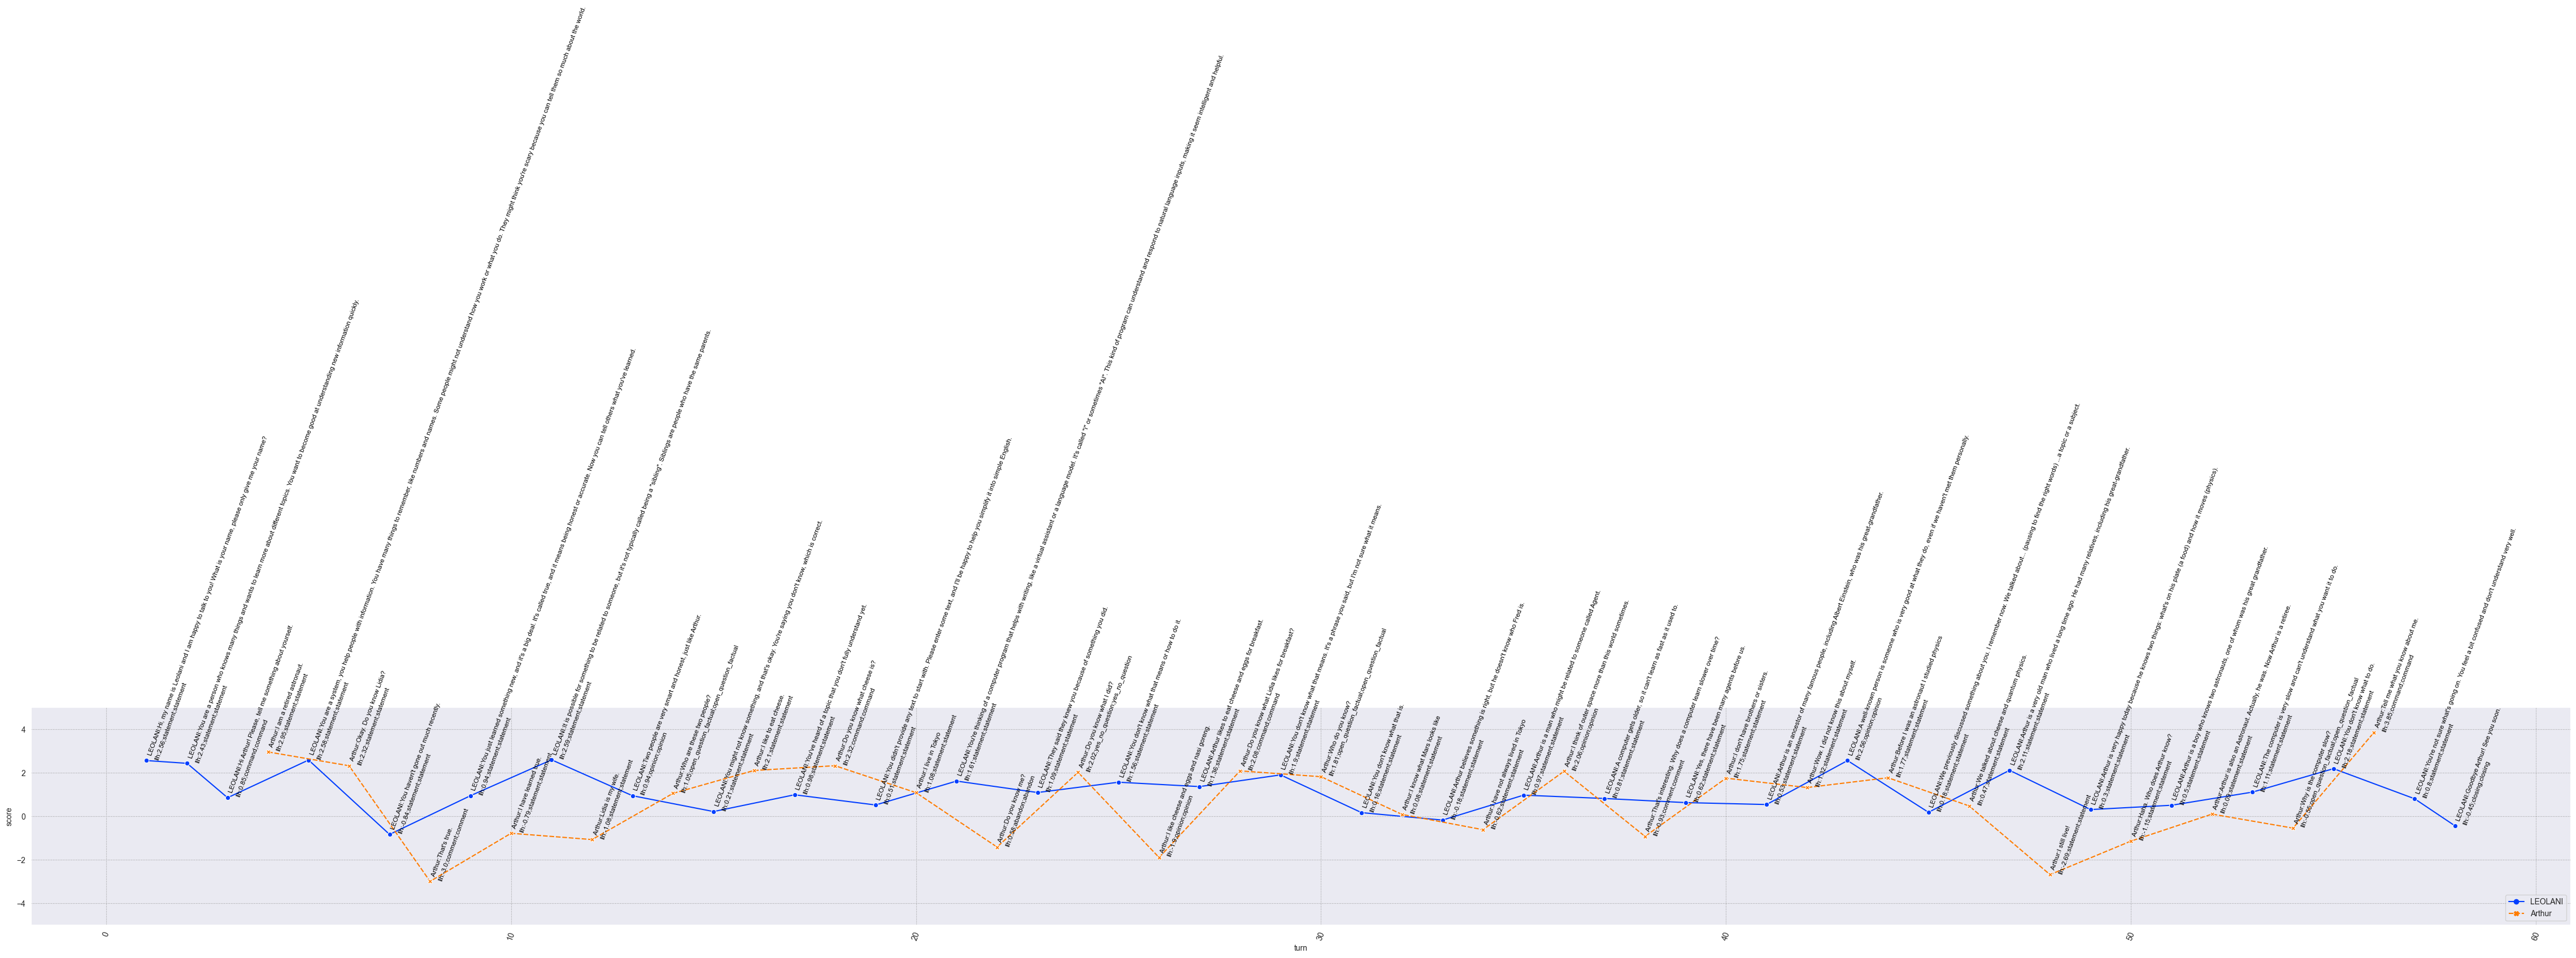

da181613-2ca8-4b85-b42c-41bab5e26057


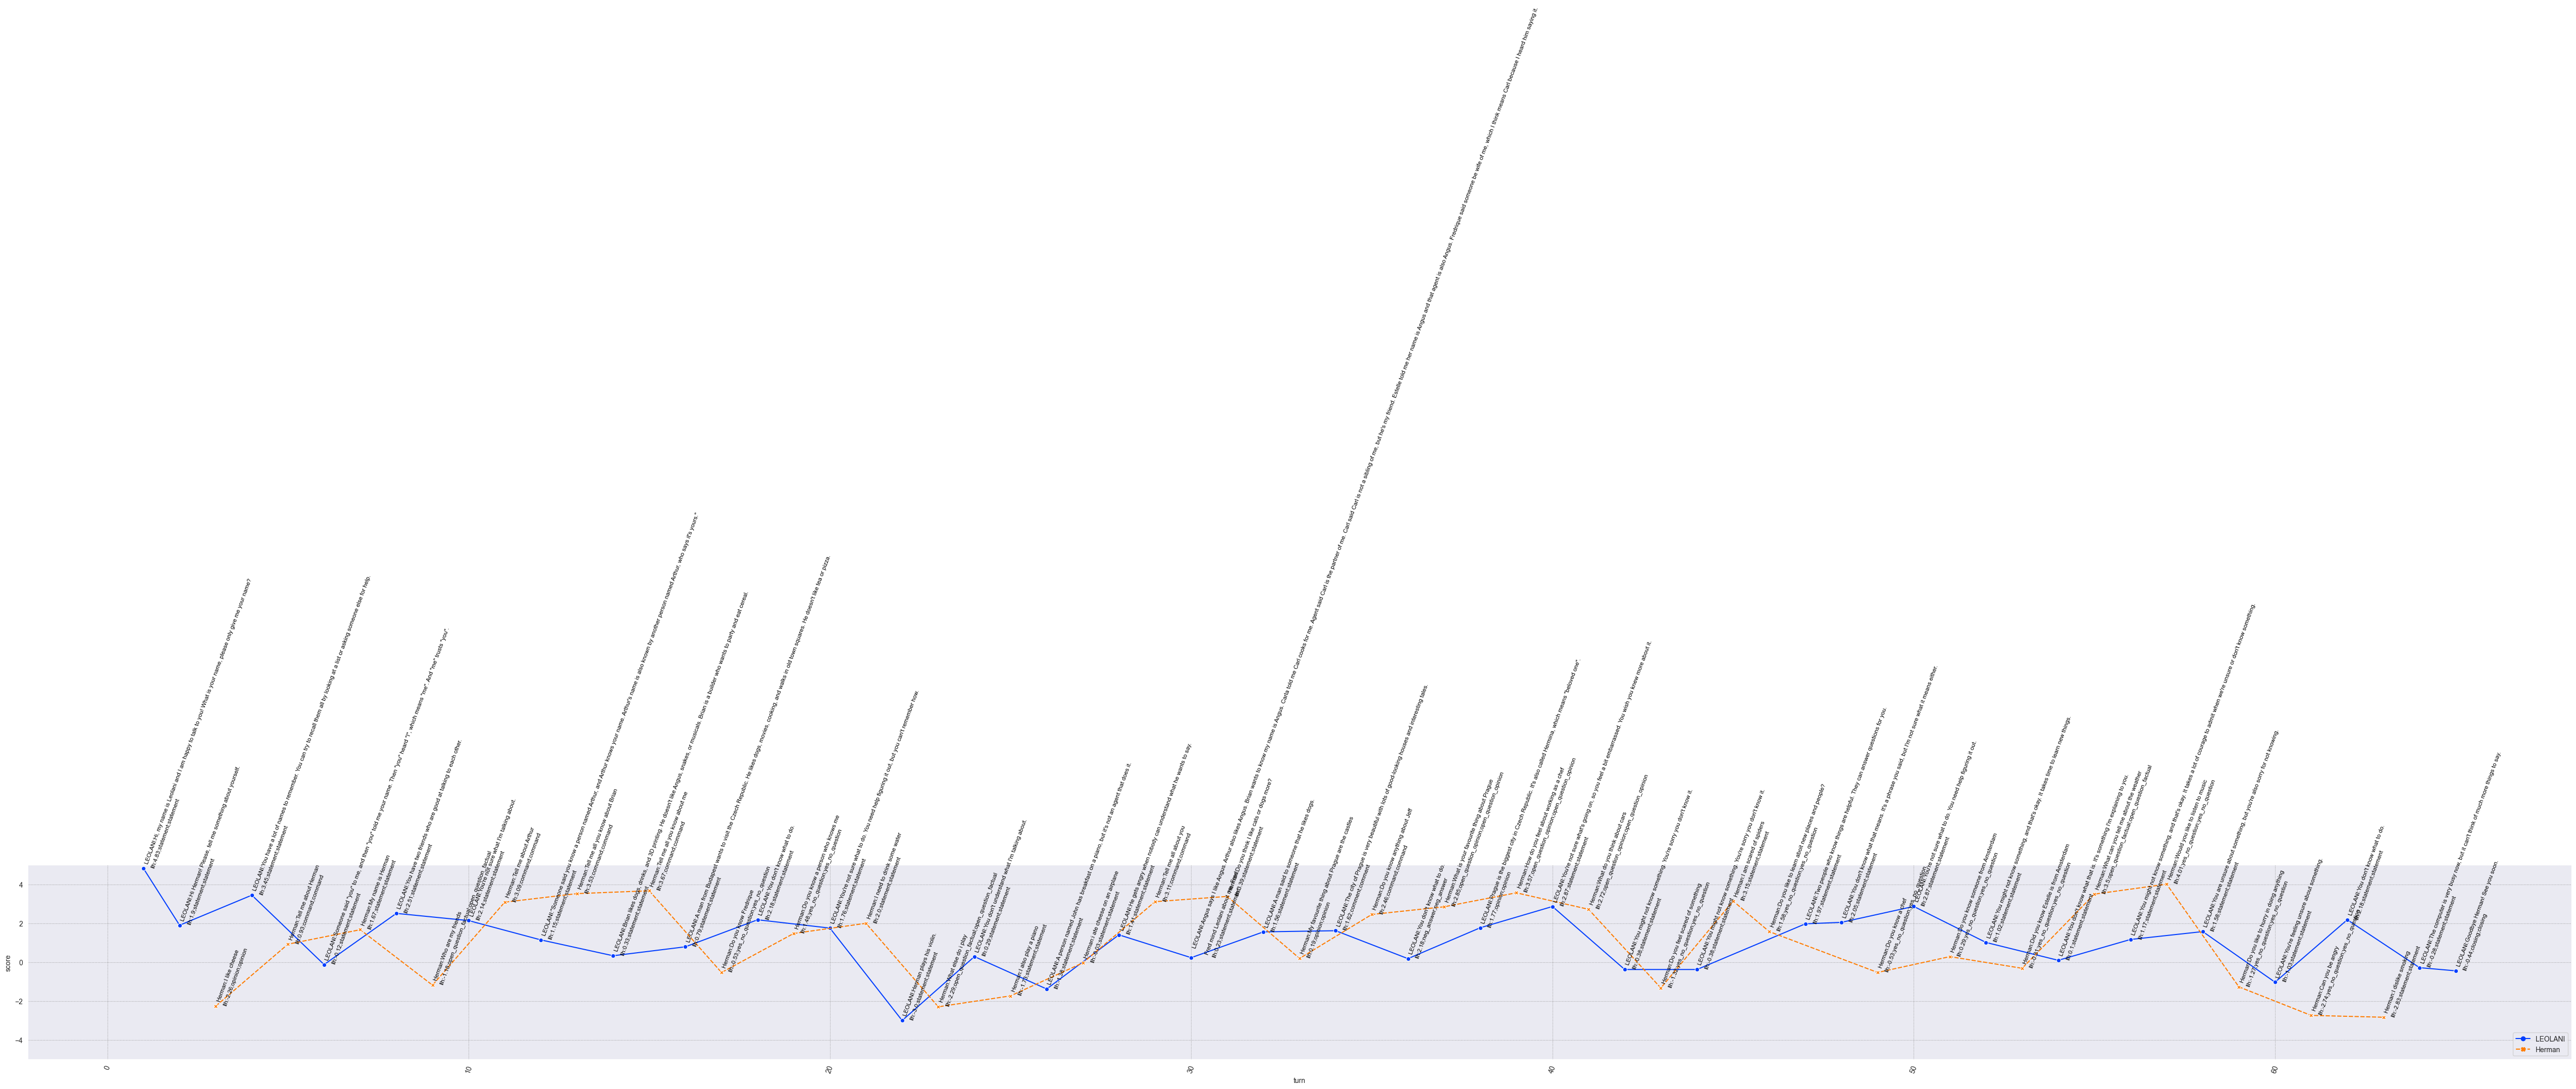

d1be965b-7b8b-4038-8f32-39b9e00467ba
No agent name in context


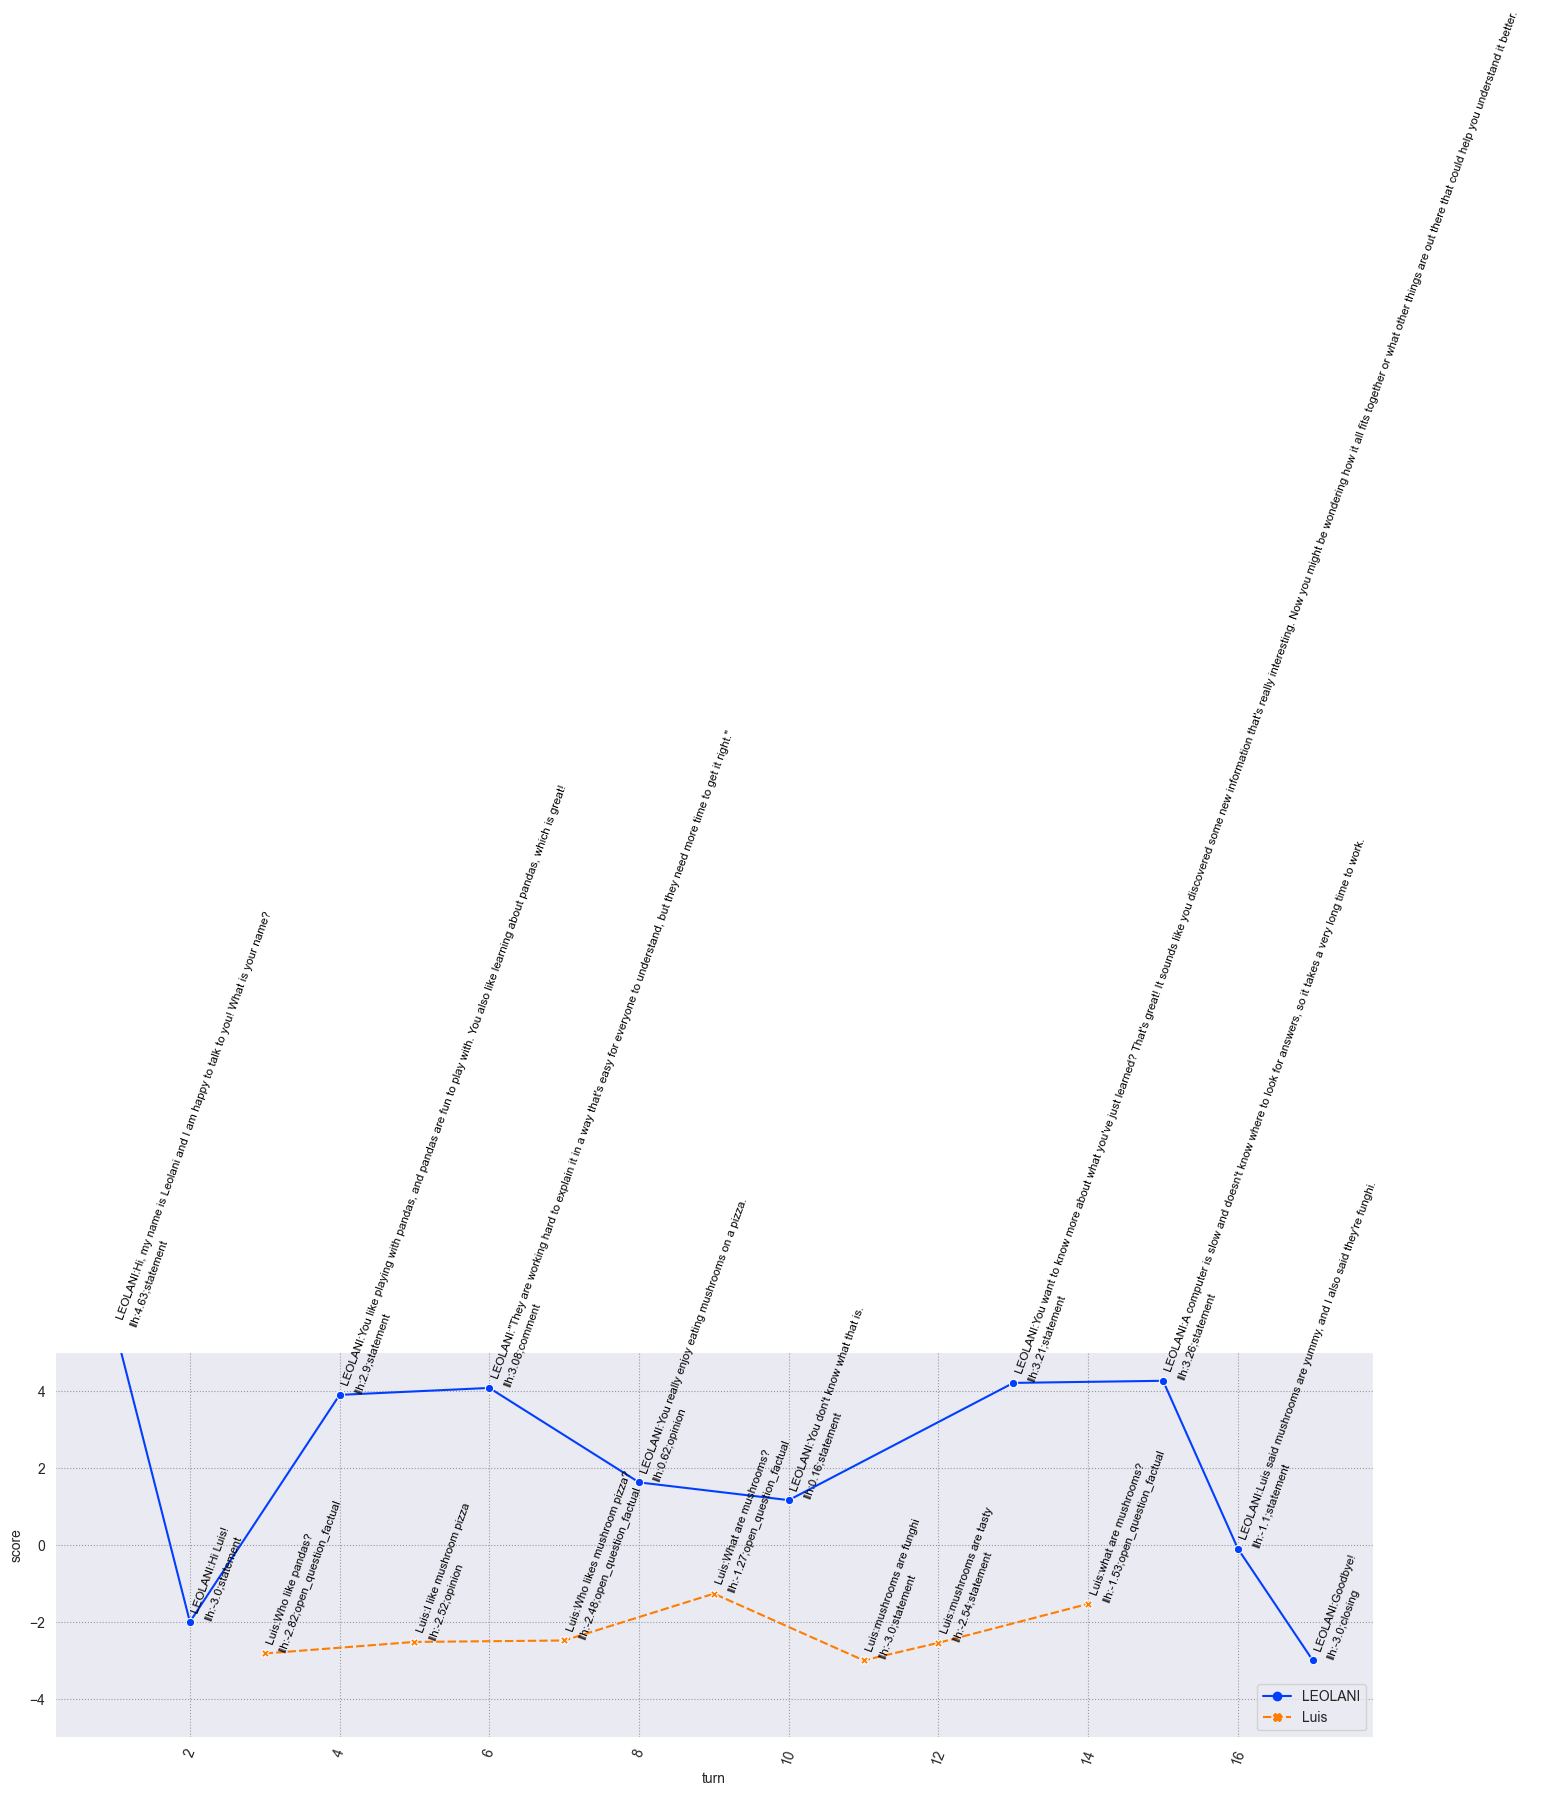

56f589fe-3cd2-4600-b7d3-7d57df2cc38b


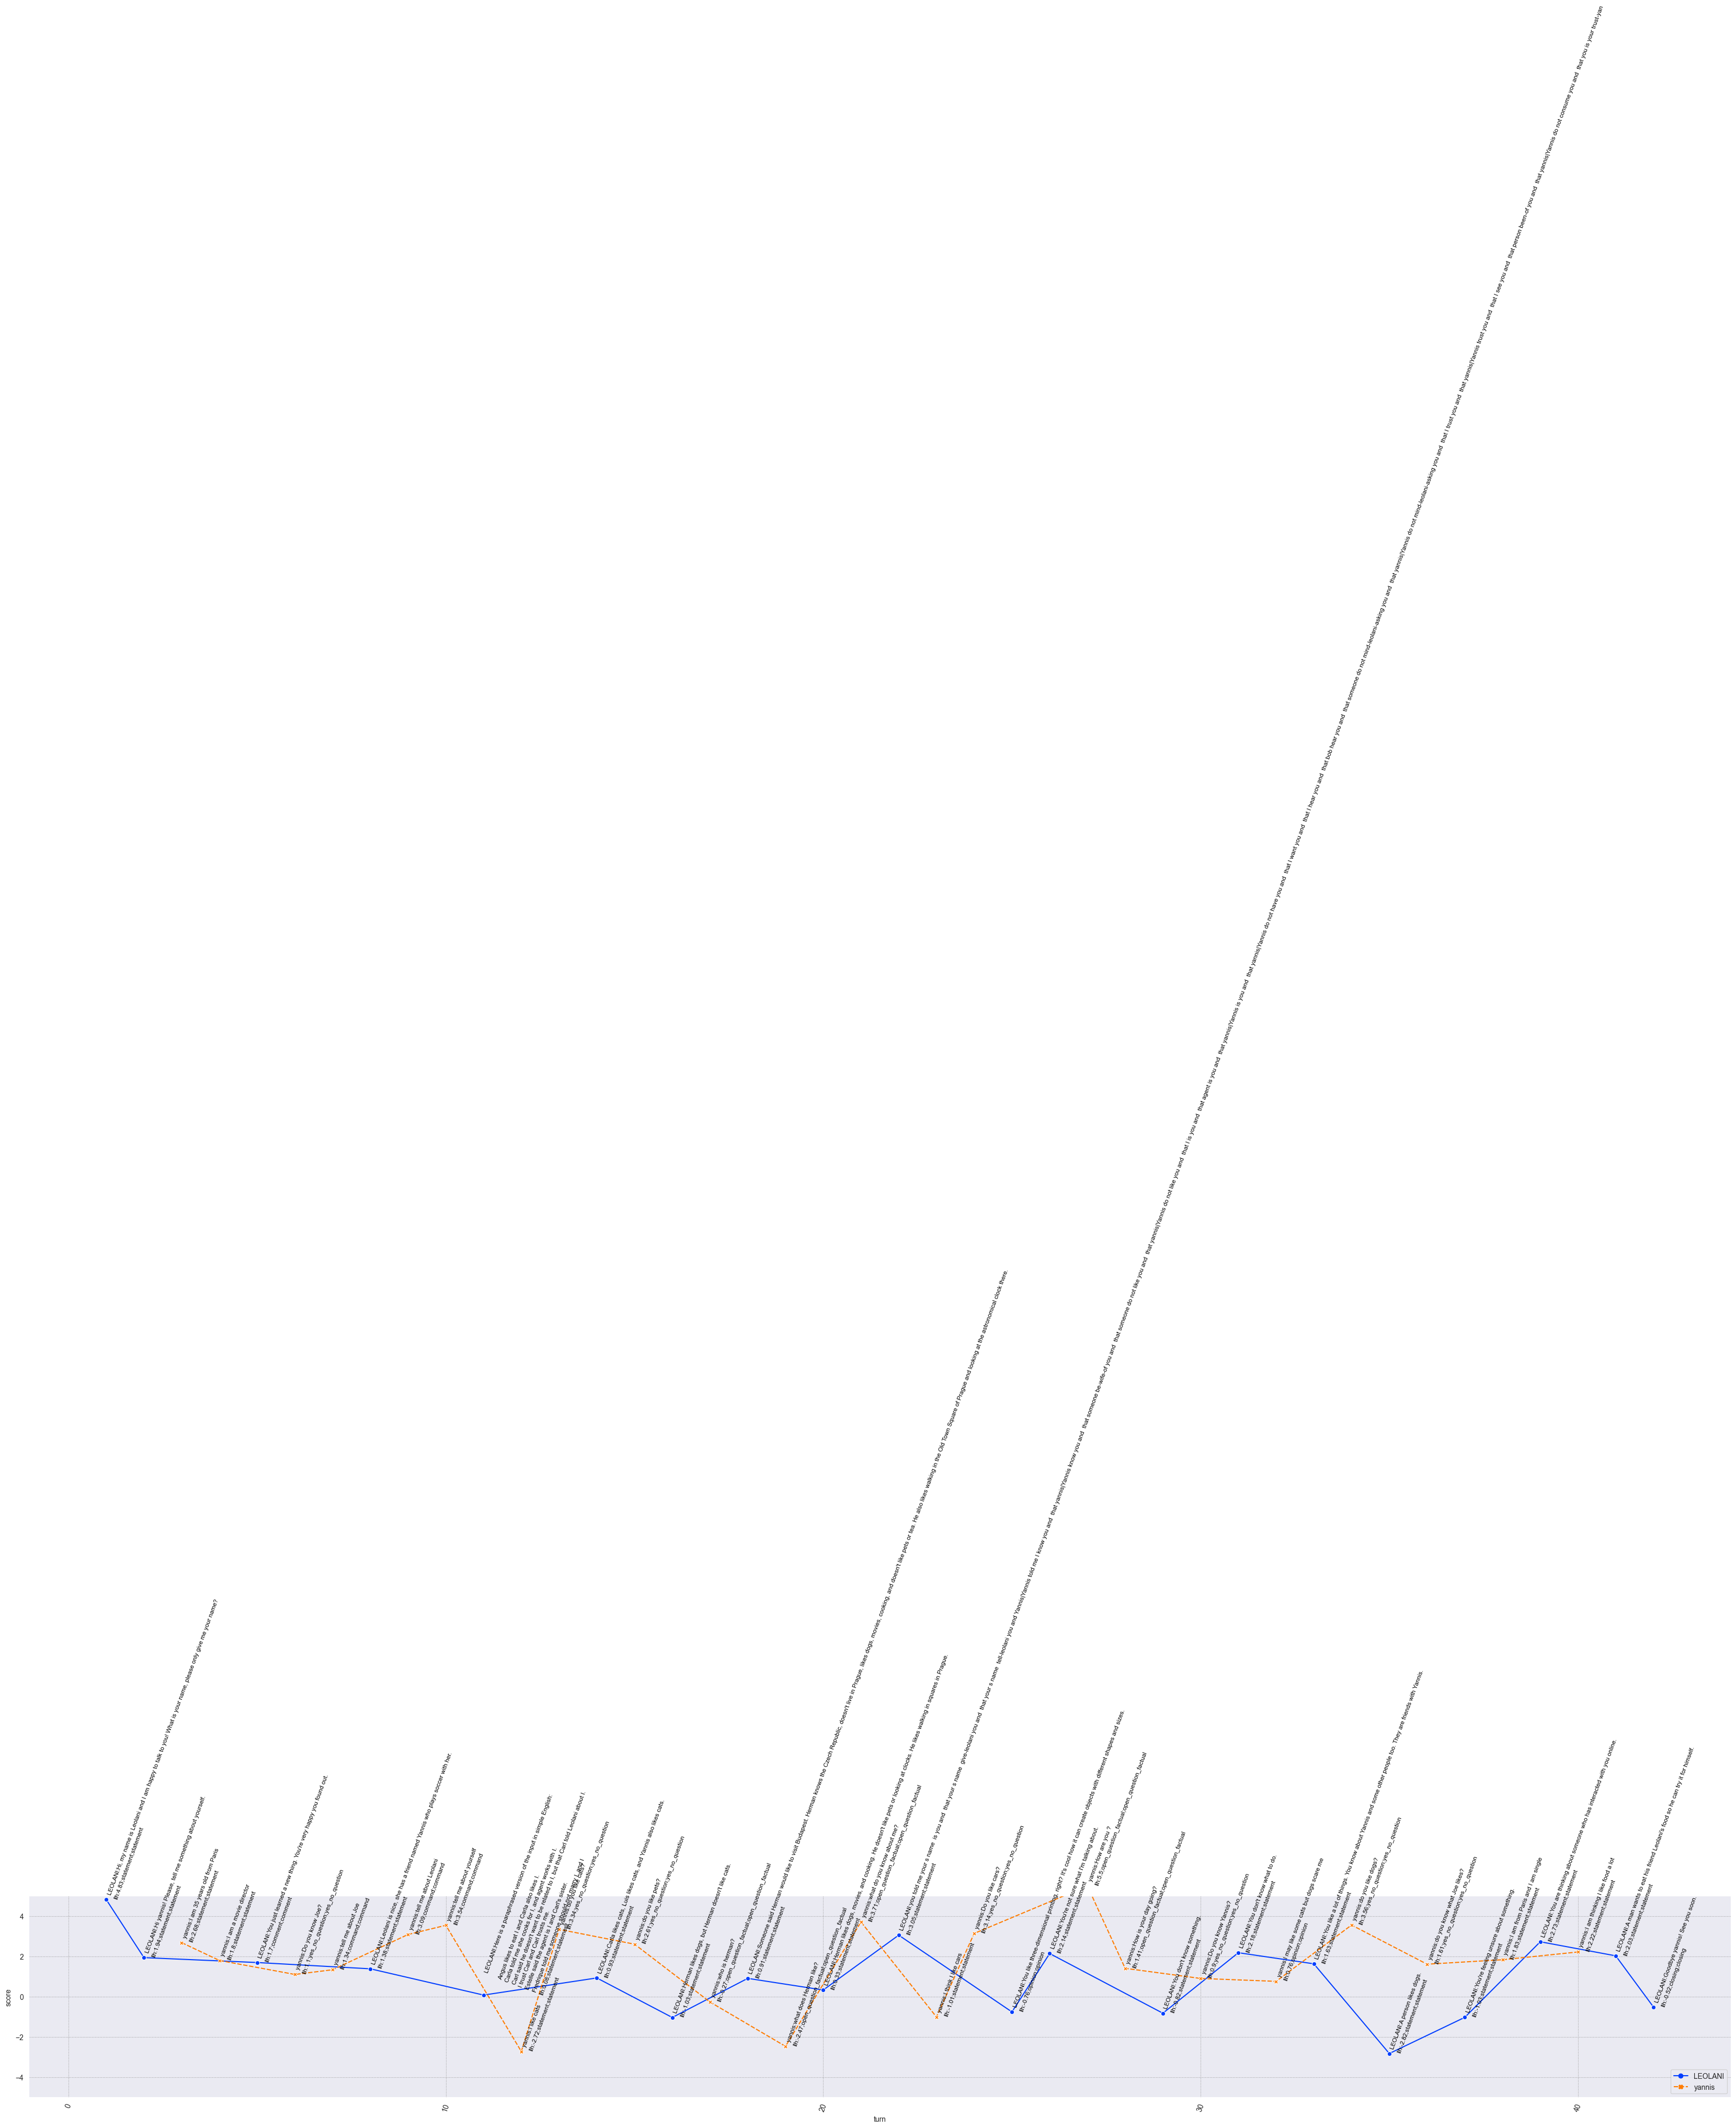

58cecec9-84f9-408c-bdf0-68a7851949a0
No agent name in context


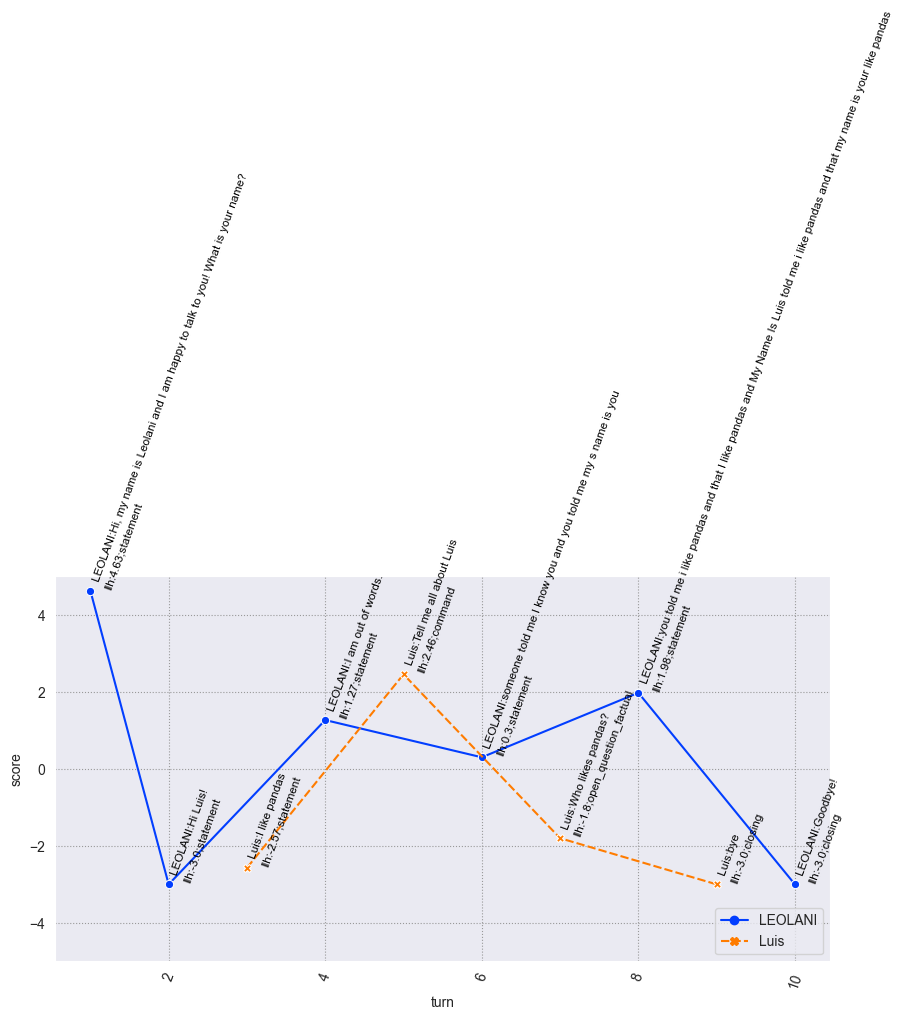

04ef831b-4f23-4890-a237-0e05ebd9521b
No agent name in context


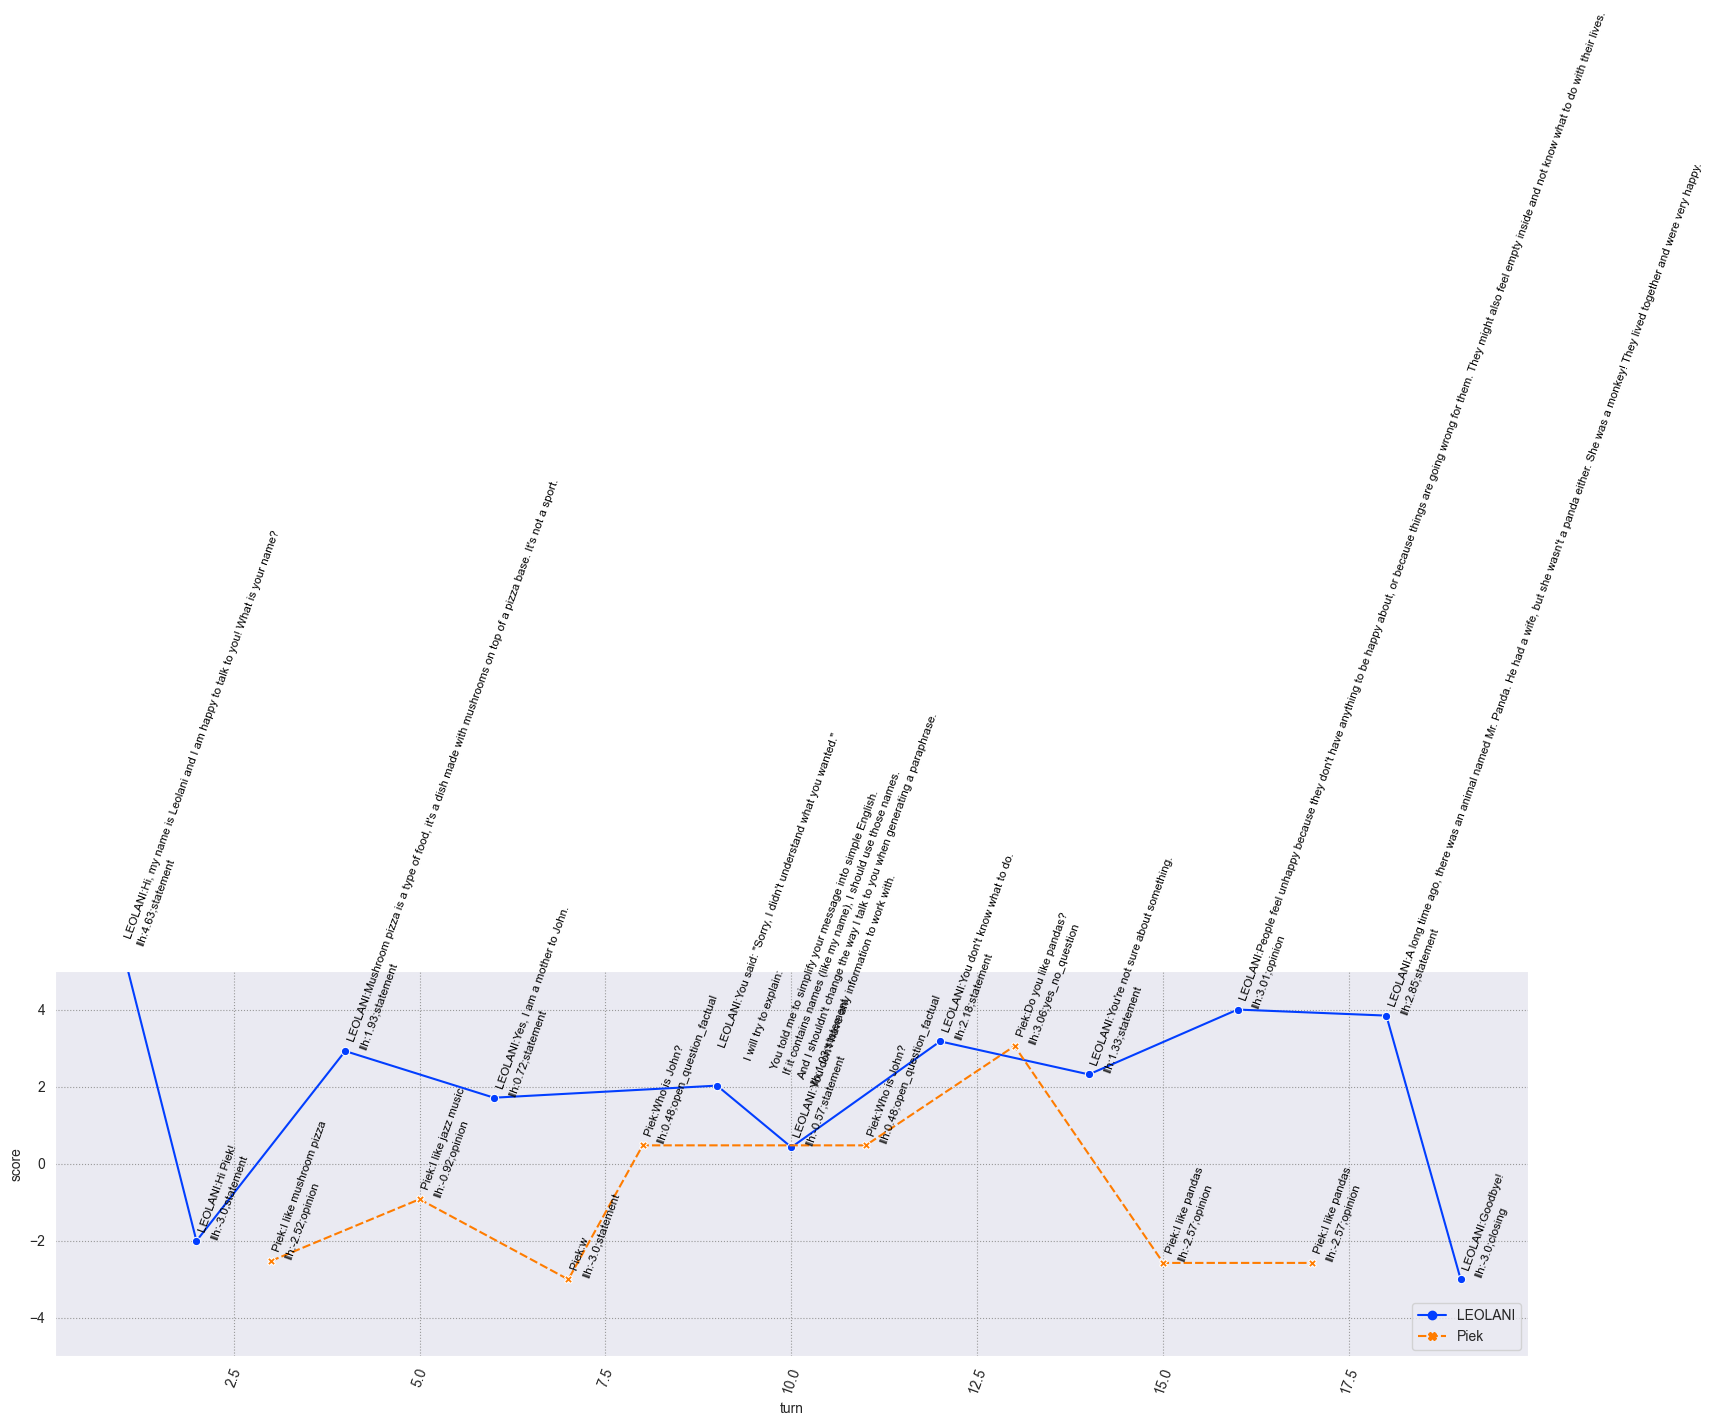

7034cb34-f776-4fb9-a007-820cb8f9876d


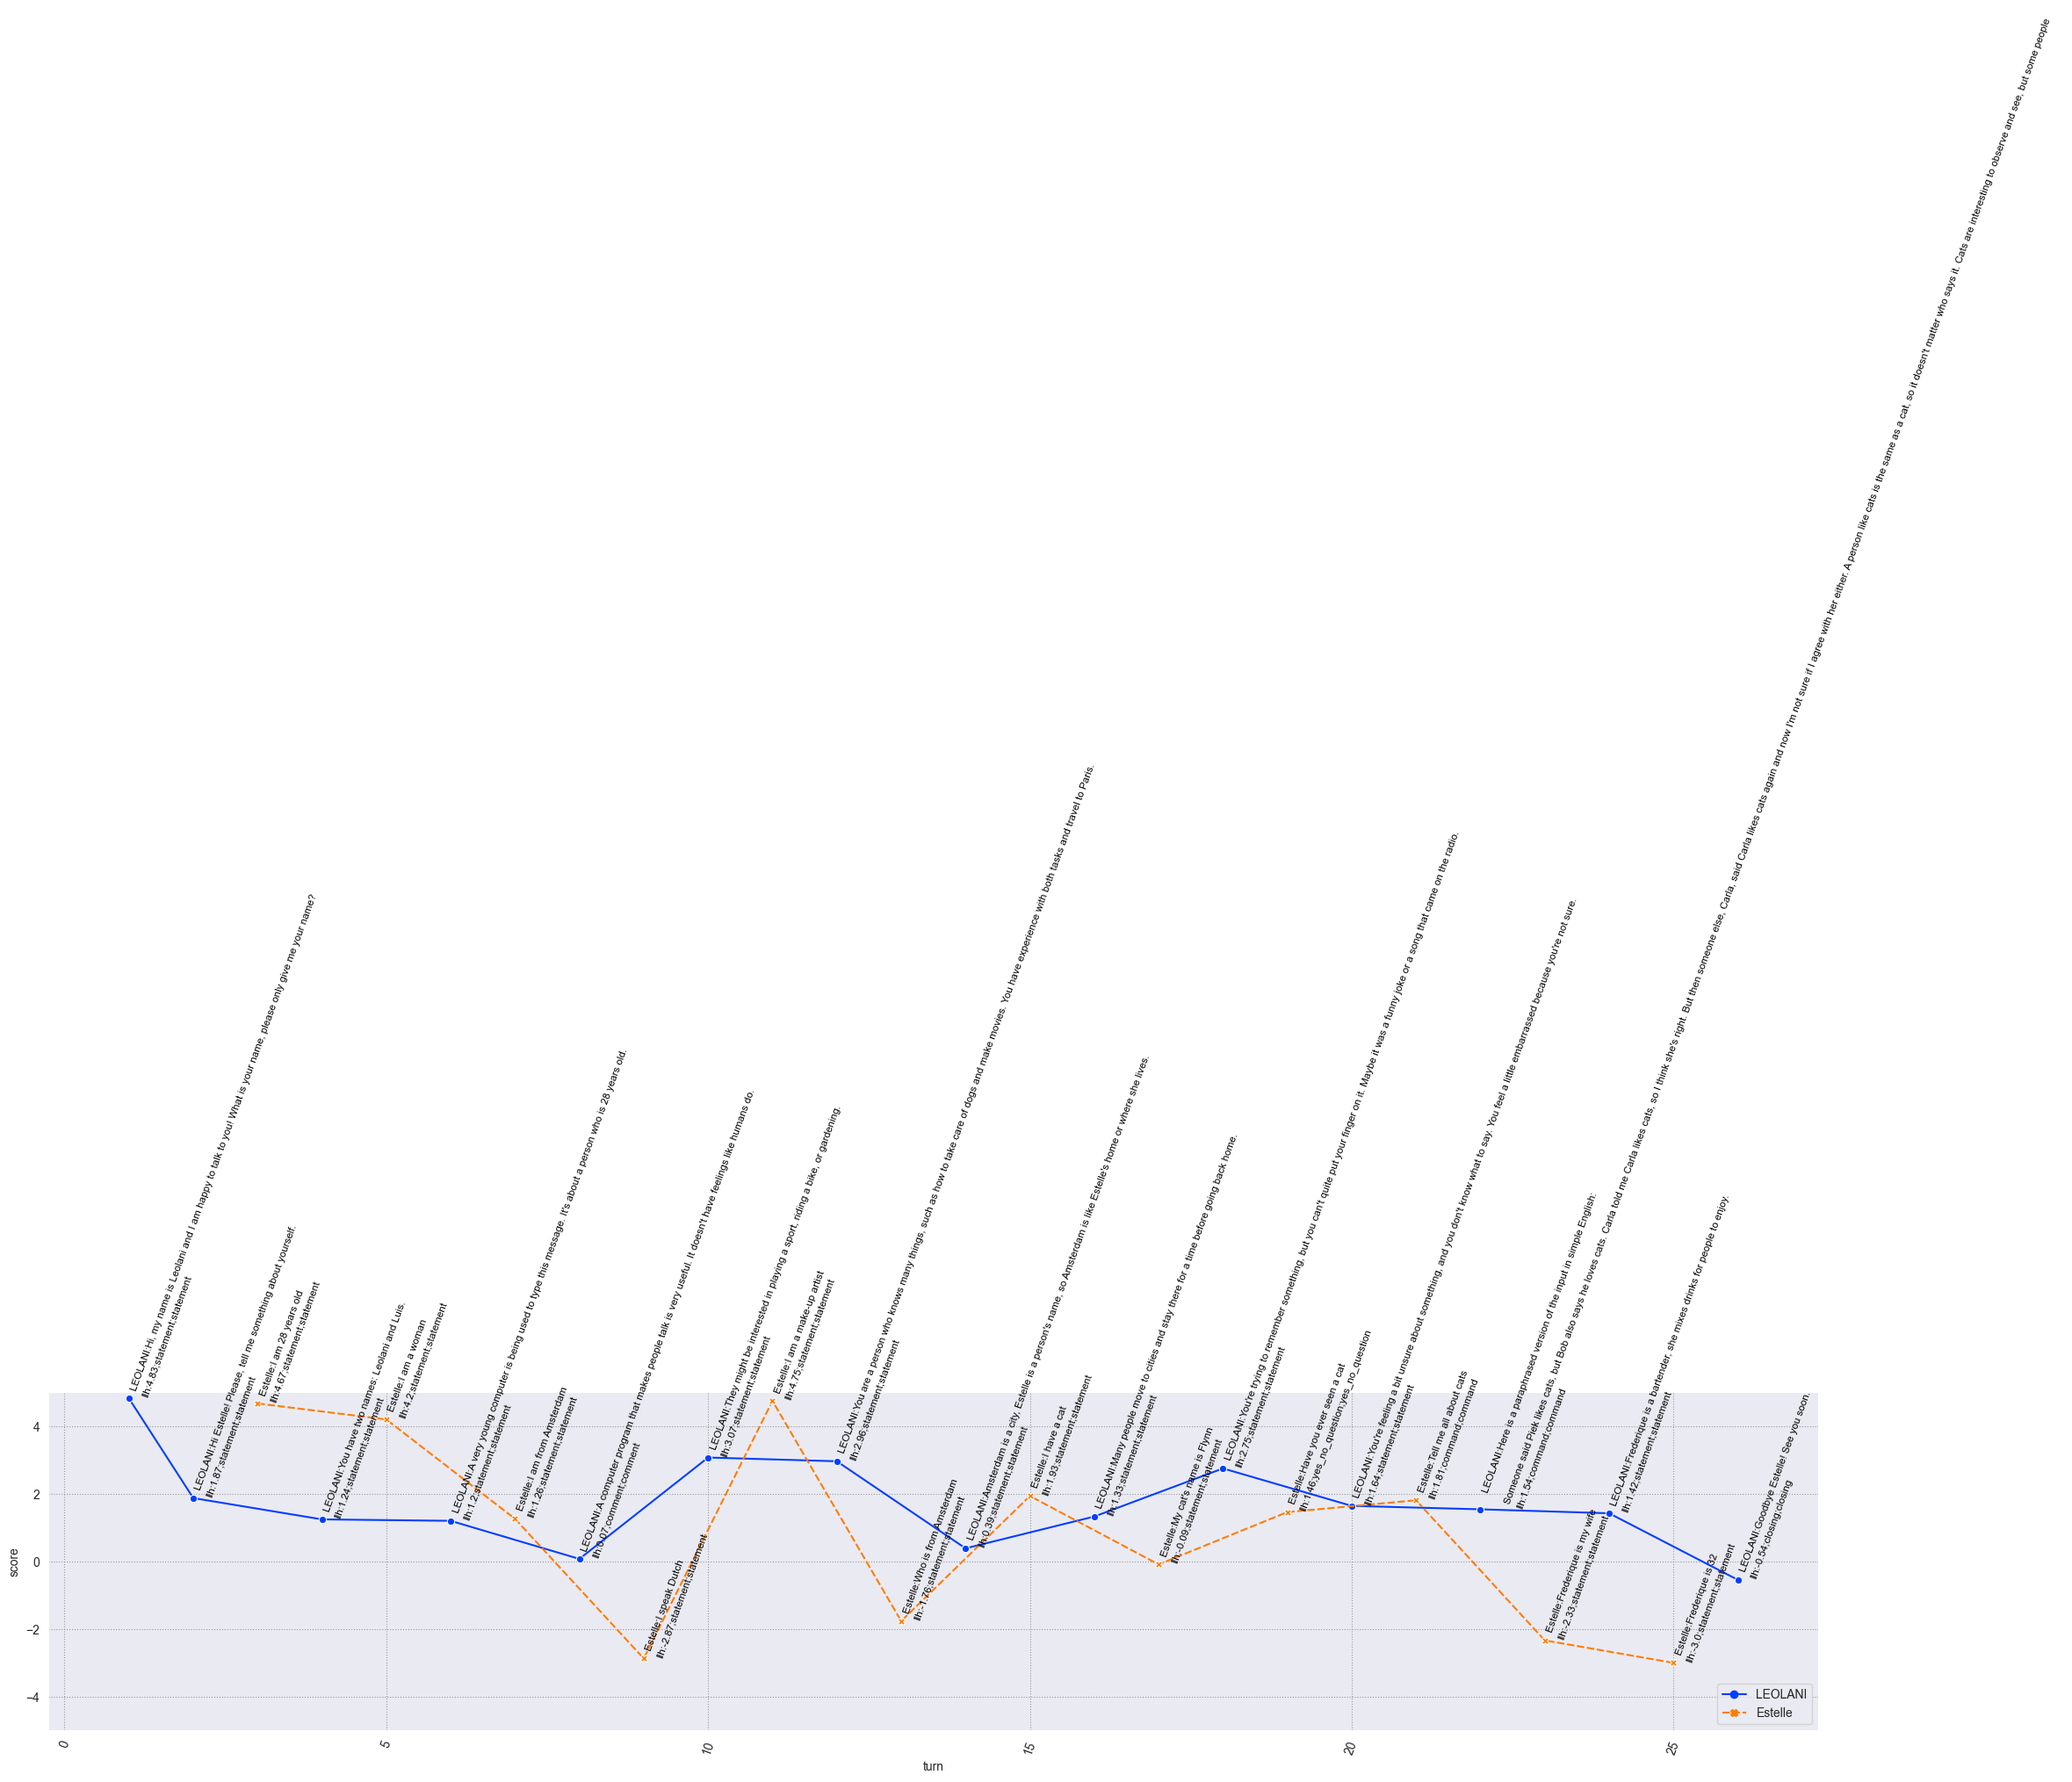

b4ad4f7f-f479-4e53-a25a-ea93eaa87445


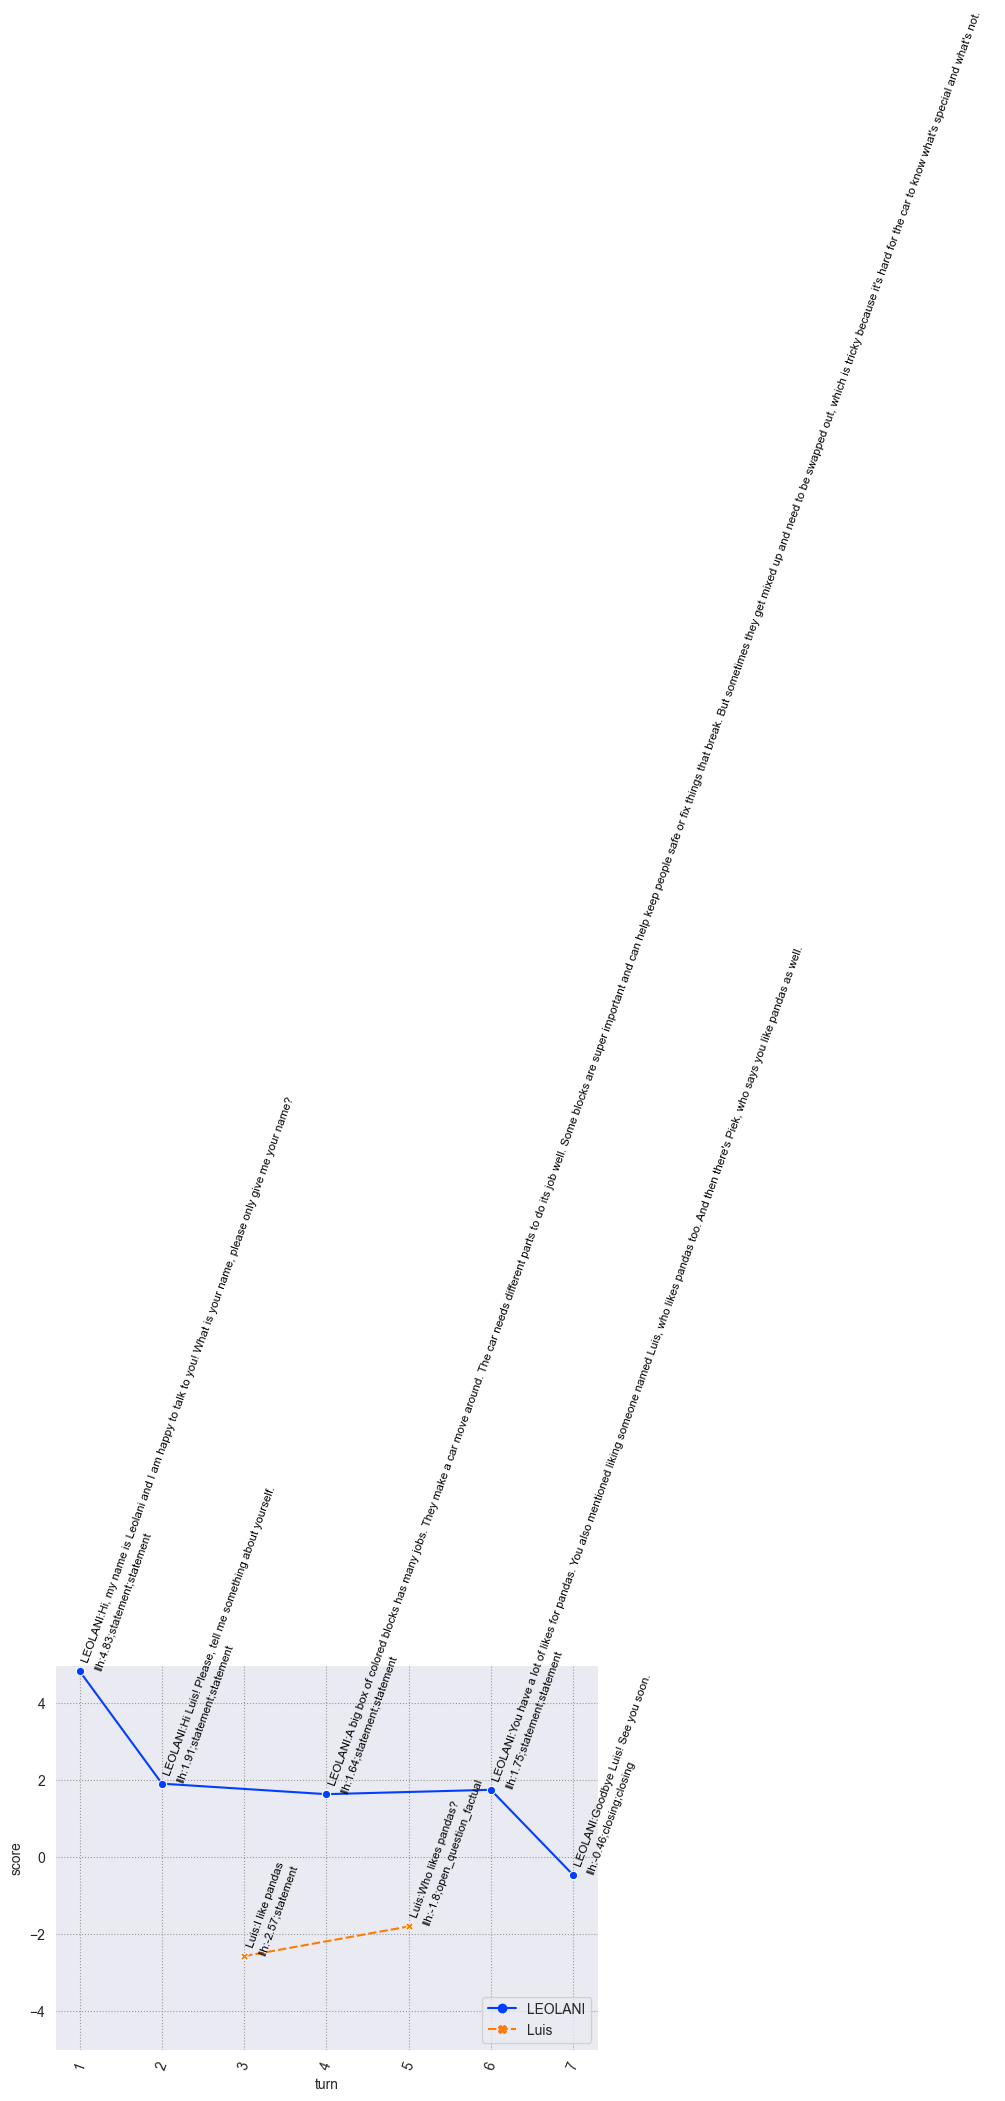

7e9a83e6-e89c-42ef-90a4-6919bd74b333


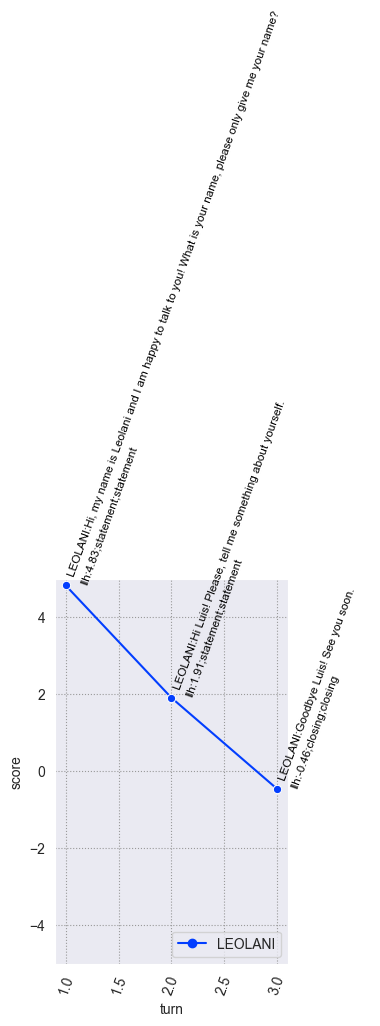

e214b94d-5d63-4151-8bea-274cdc9f0c29


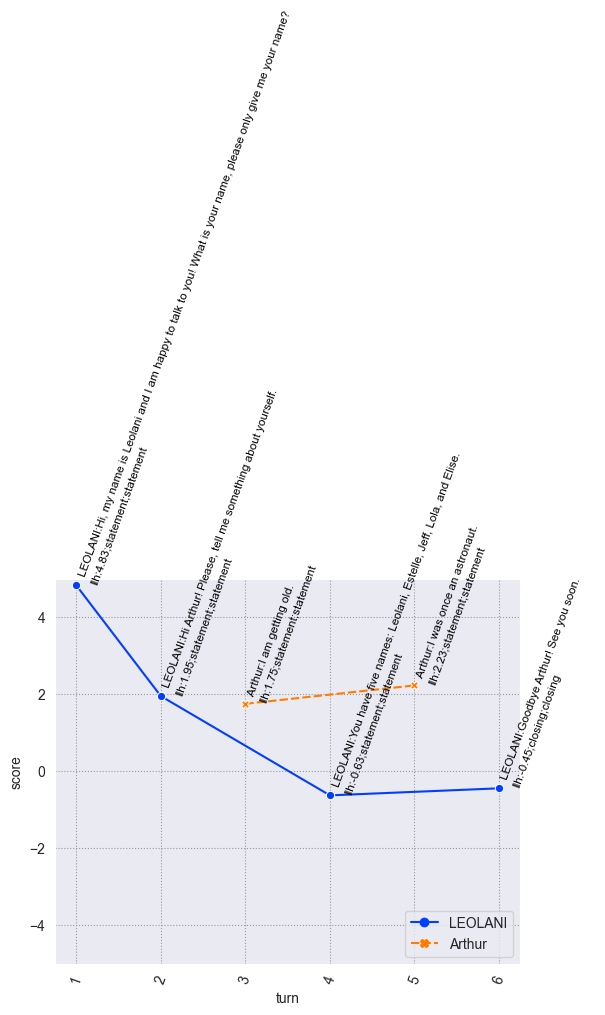

28b2ecd4-29c9-411e-aab5-c5b603fbcbcc


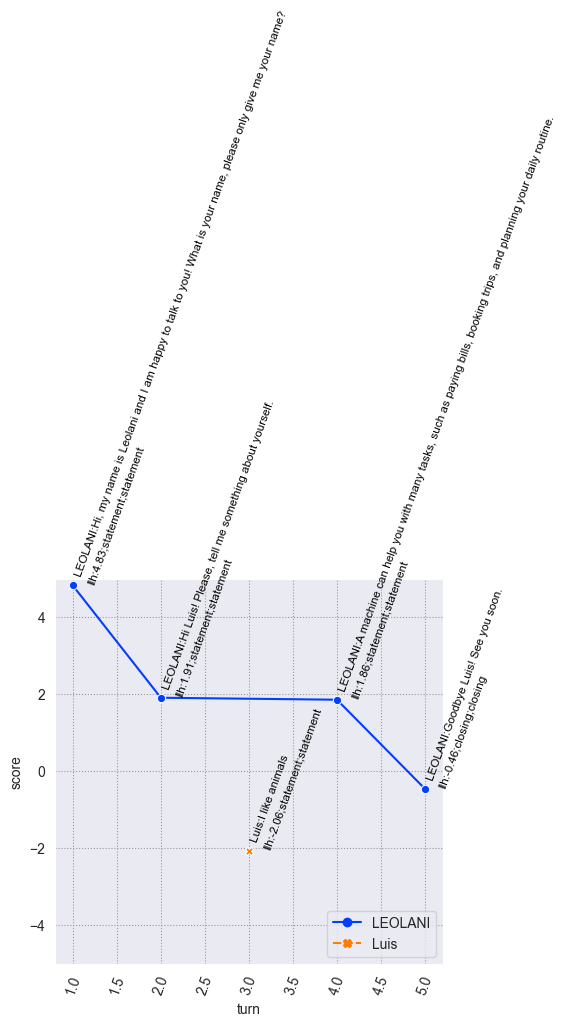

b078942c-a560-419e-a03b-8bb40c3ea5df


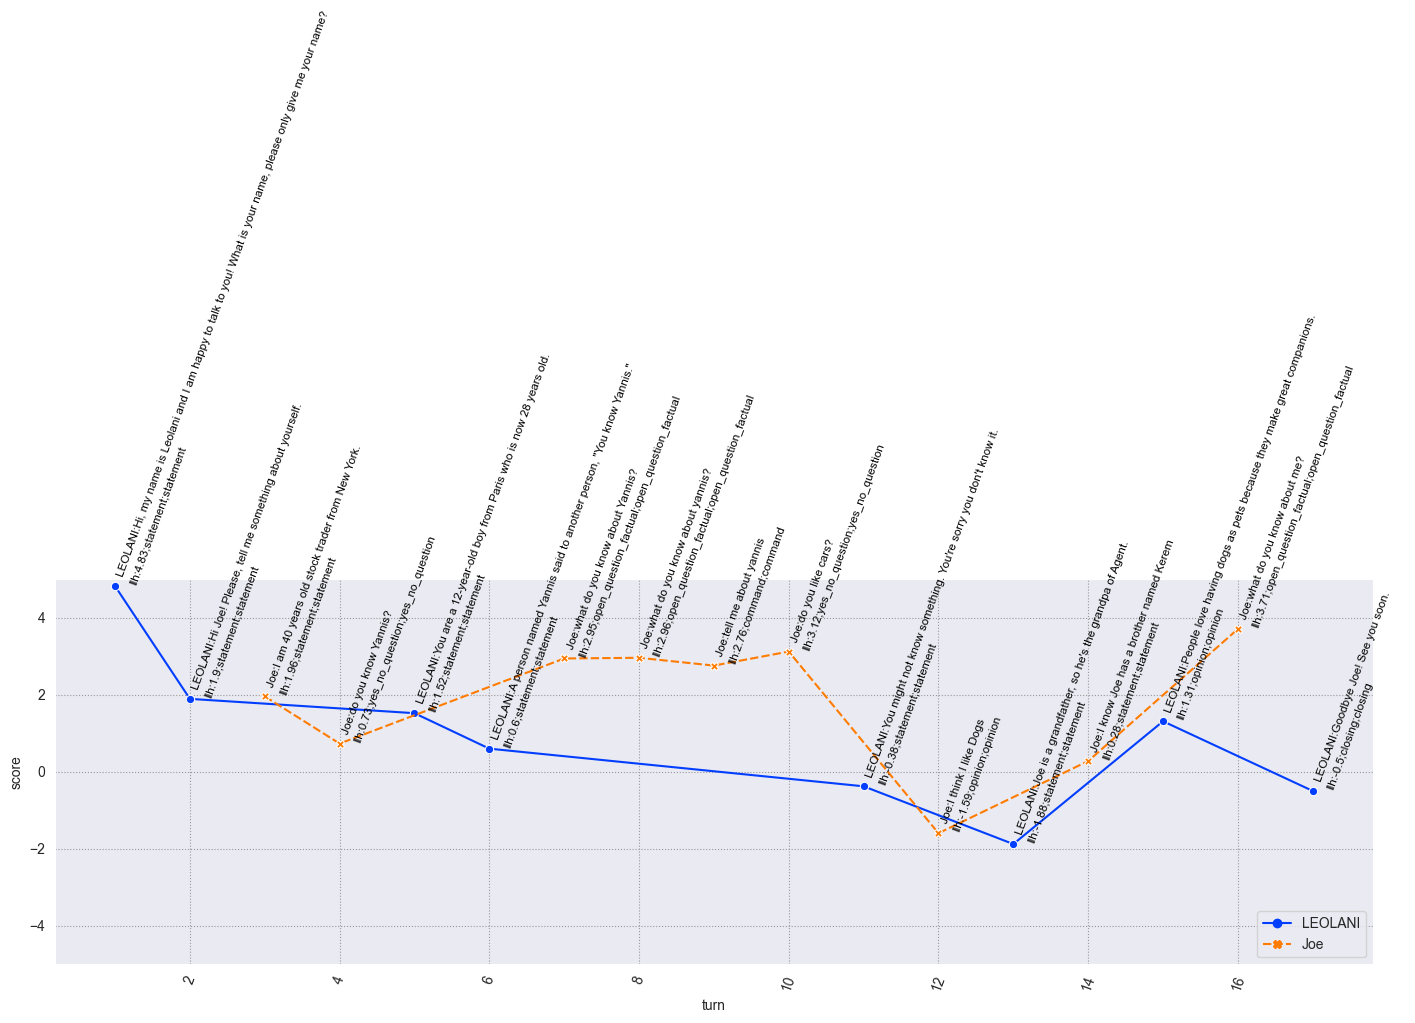

2888cb83-8722-47ab-93be-f75c24a06d9d


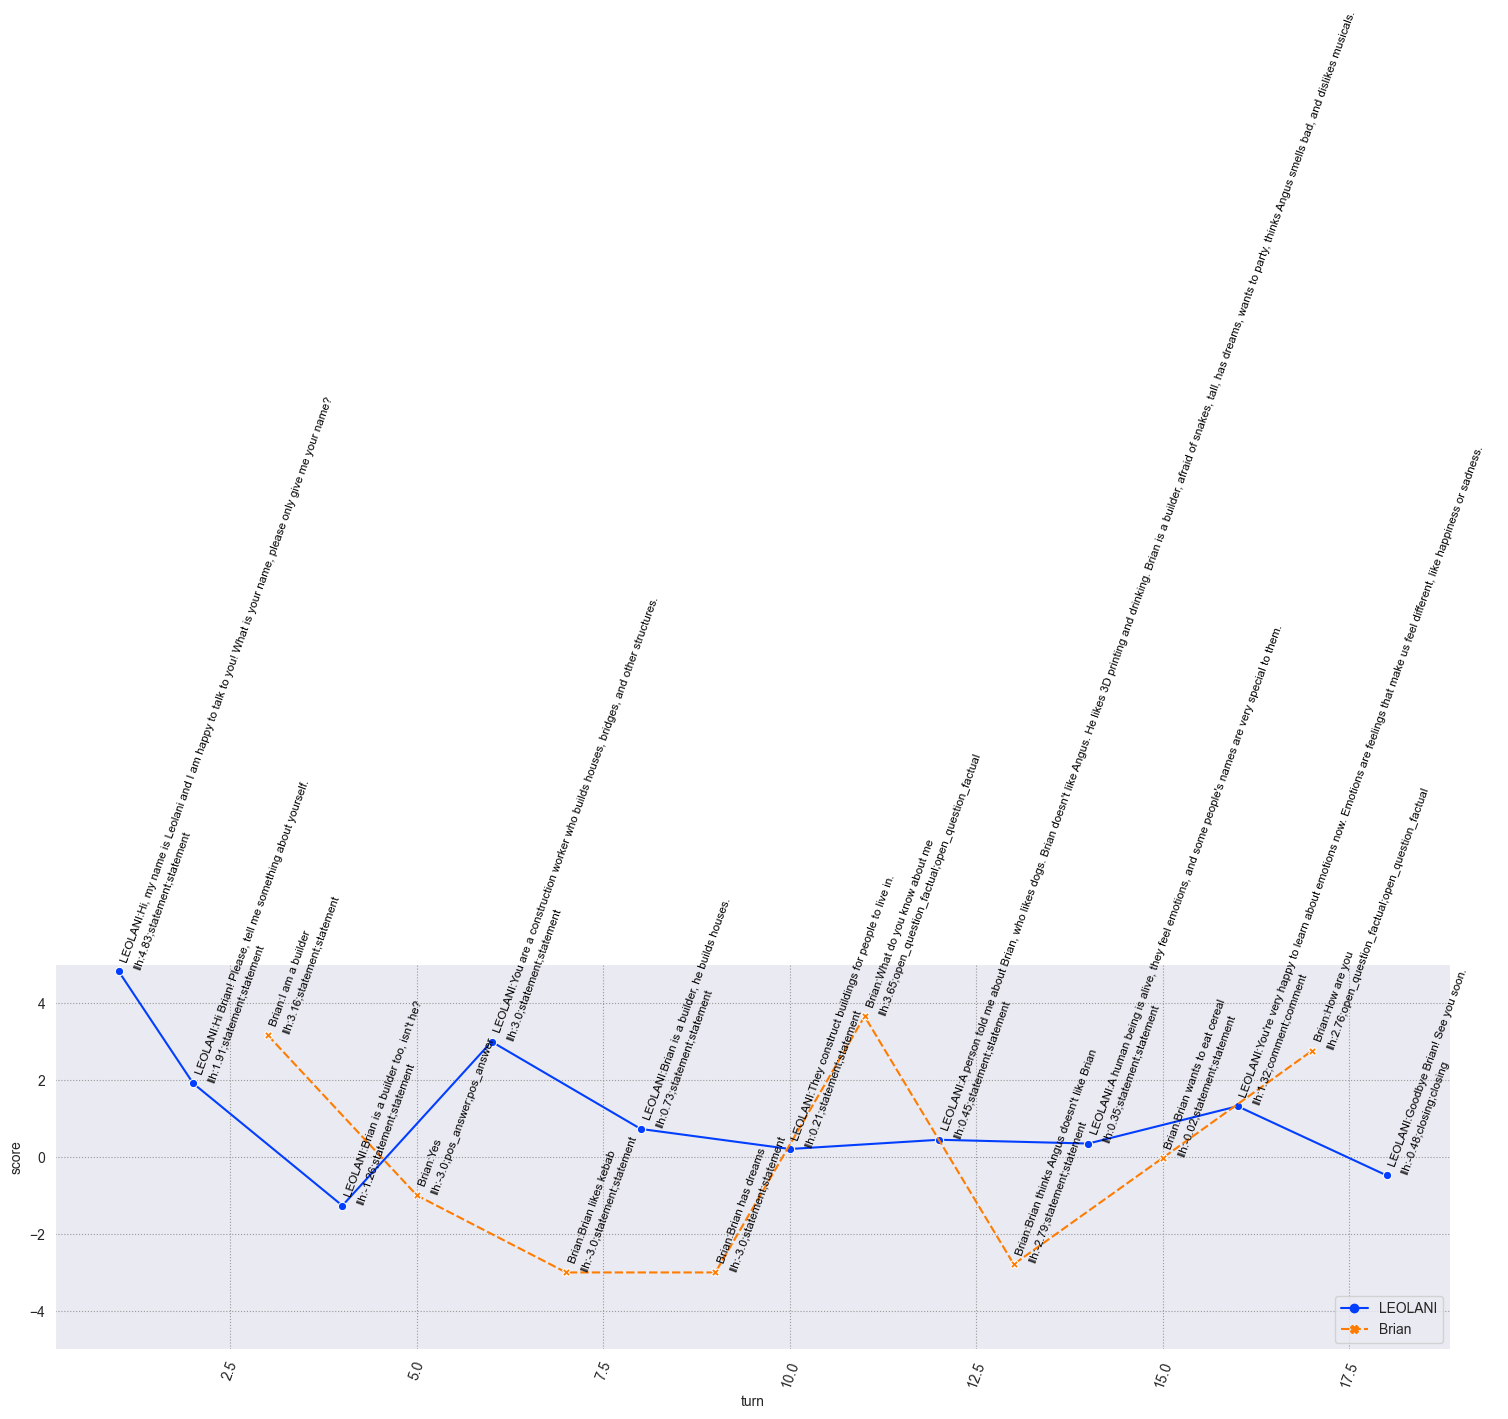

9edaa24e-4fa1-4e5b-a9d5-ff7576398fe7
No agent name in context


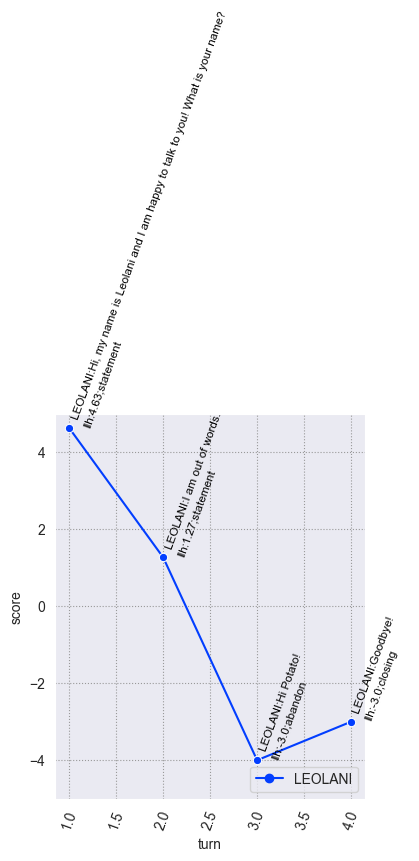

1dde4b52-886c-4c19-839f-16b49e76cfc9


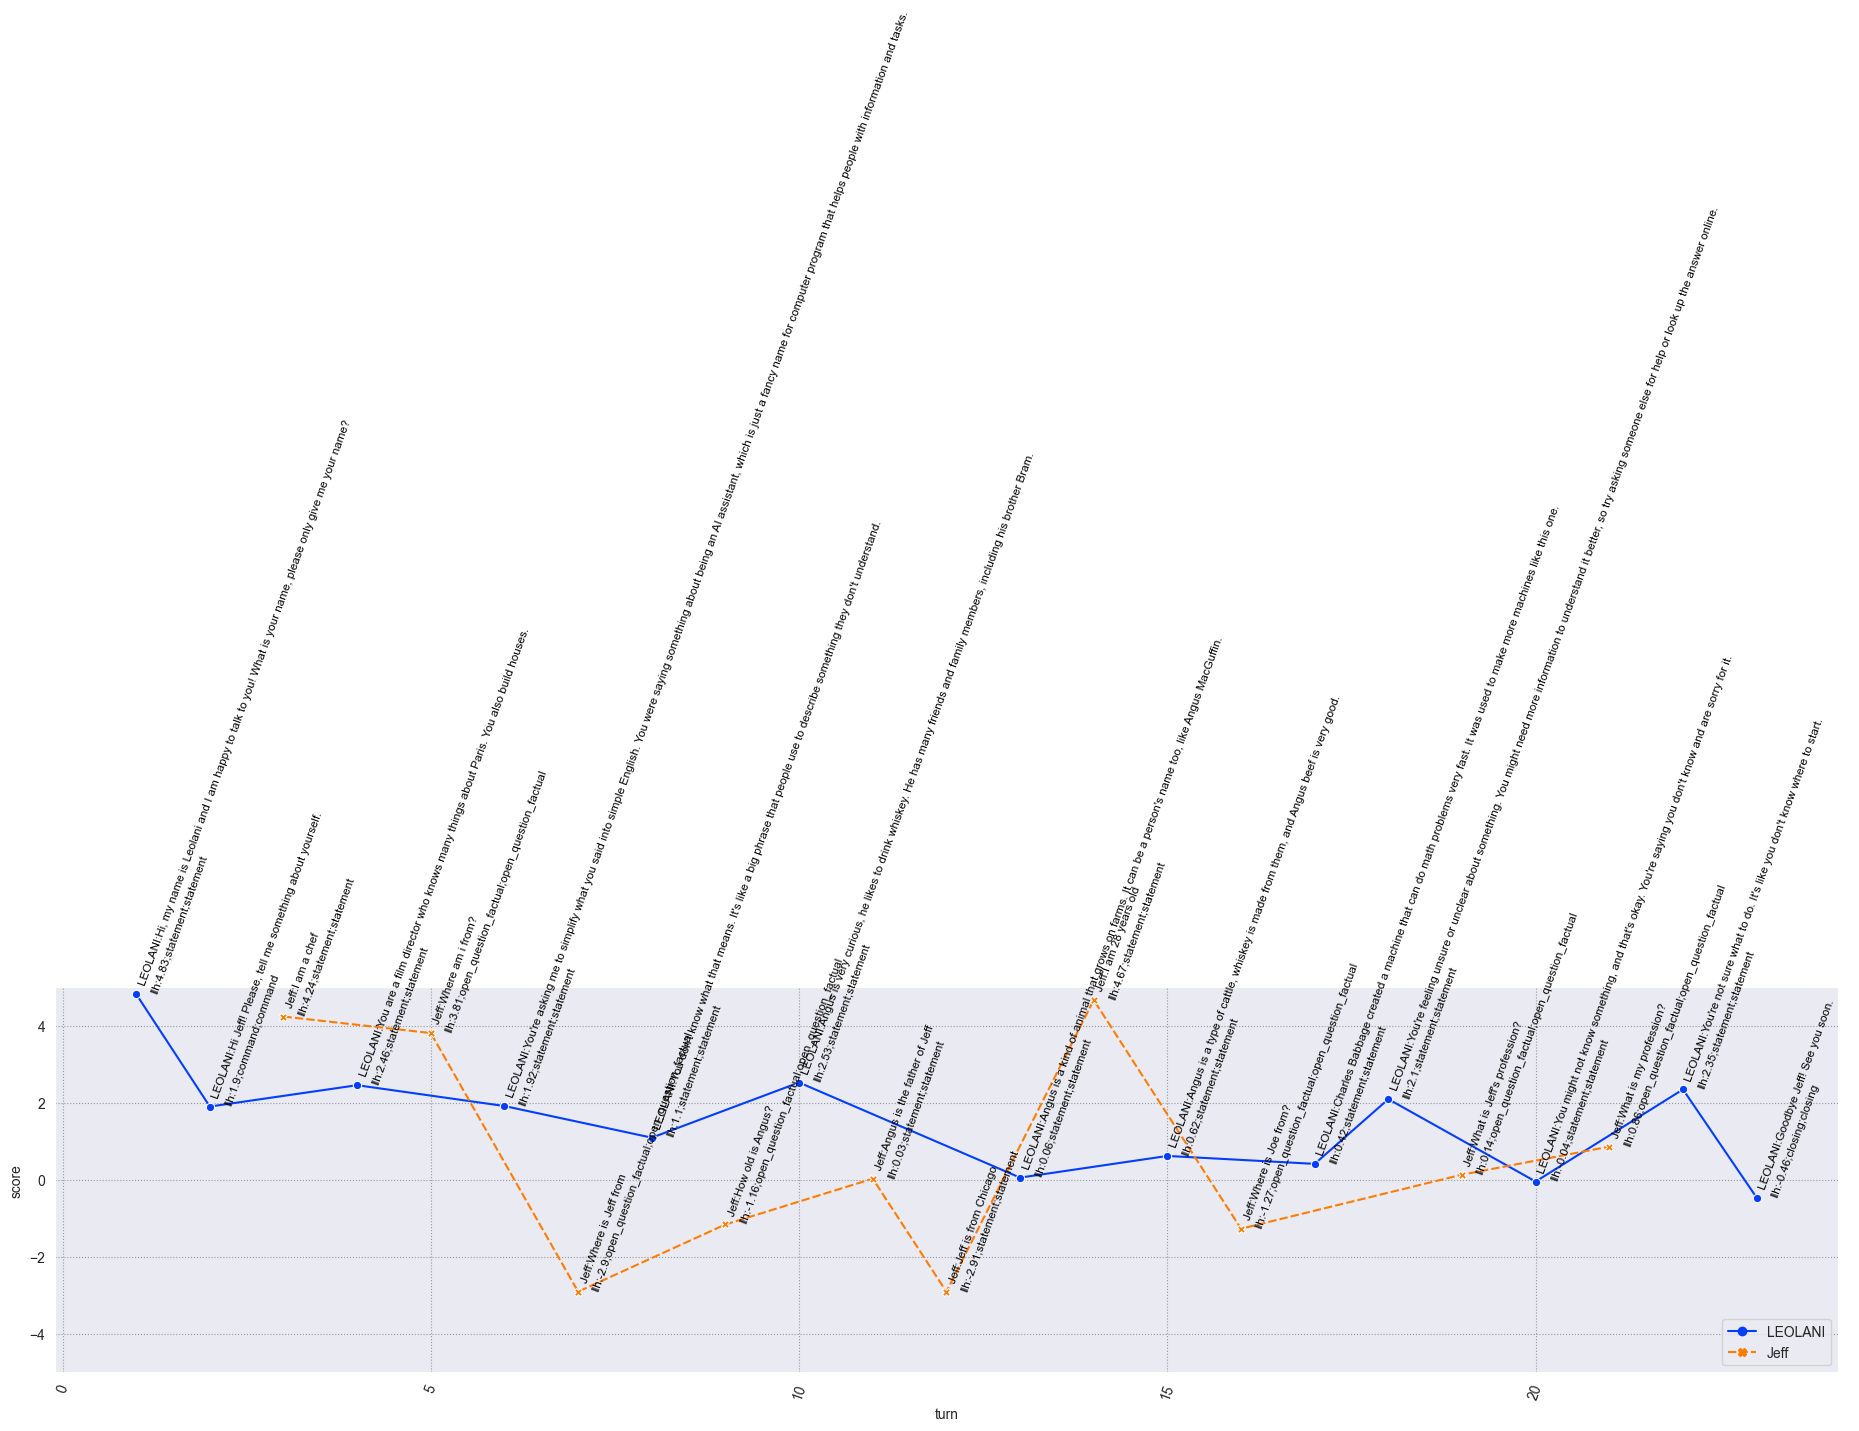

eca900b6-5aec-456f-9ab5-00f120ebc0b1
No agent name in context


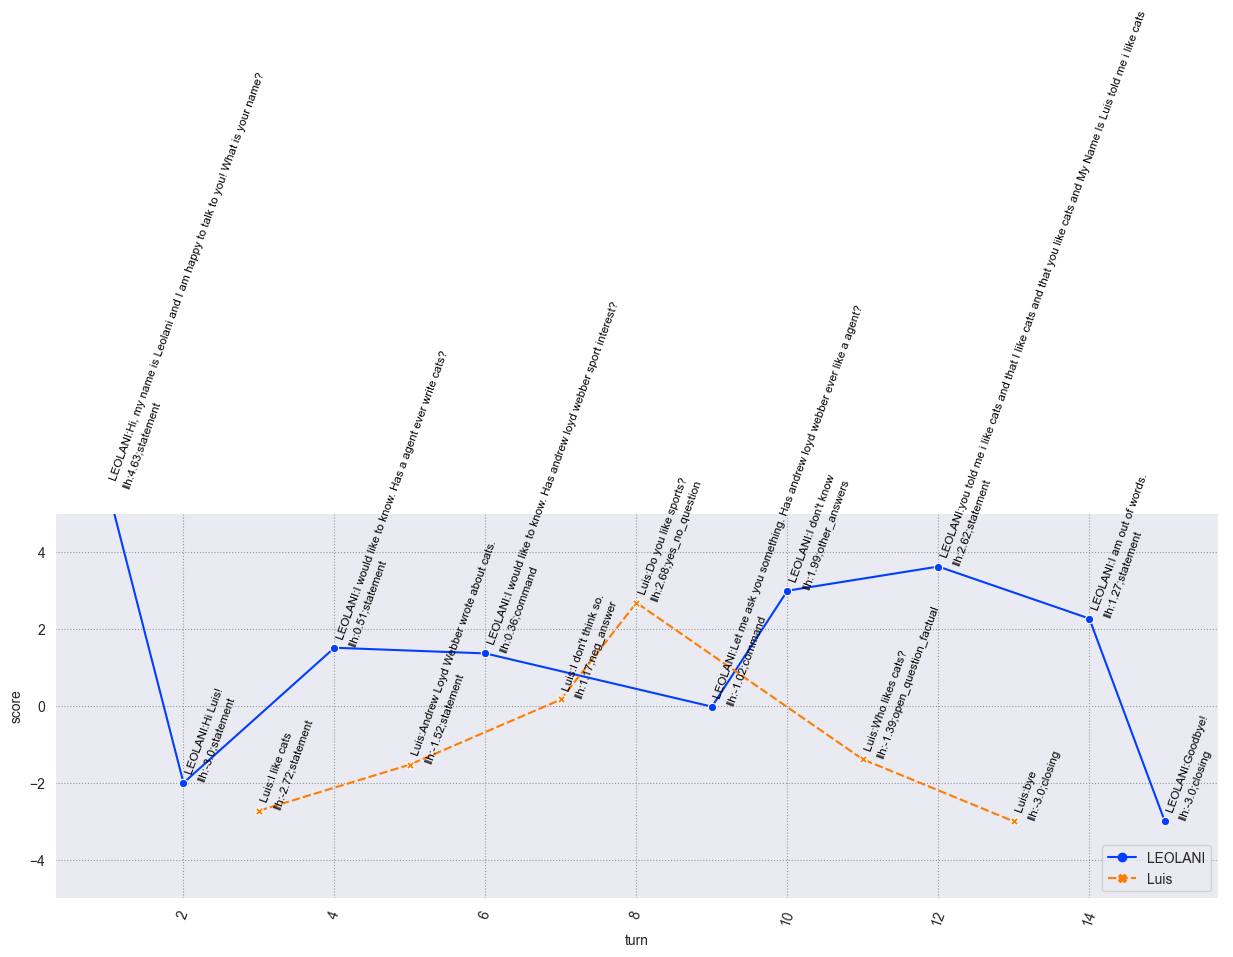

In [21]:
for SCENARIO in scenario_folders:
    print(SCENARIO)
    ### Extract the plot image for scenario with the settings defined above
    plot.create_timeline_image(emissor_path=EMISSOR, scenario=SCENARIO,settings=settings)

In [22]:
for SCENARIO in scenario_folders:
    print(SCENARIO)    
    scenario_path = os.path.join(EMISSOR, SCENARIO)
    rdf_path = os.path.join(scenario_path, "rdf")
    if os.path.exists(rdf_path):
        graph_evaluator = GraphEvaluator()
        graph_evaluator.evaluate_conversation(scenario_path, rdf_folder=rdf_path)
    else:
        print("No triples found for", SCENARIO)

2024-11-26 08:50:36 -     INFO -                      cltl.dialogue_evaluation.GraphEvaluator - Booted


48ebae93-ae78-41ba-908a-a5f1fa2afe3d
----------SCENARIO:/Users/piek/Desktop/t-MA-Combots-2024/assignments/assignment-1/leolani_text_to_ekg_wild/emissor/48ebae93-ae78-41ba-908a-a5f1fa2afe3d, EVALUATION:graph metrics---------
/Users/piek/Desktop/t-MA-Combots-2024/assignments/assignment-1/leolani_text_to_ekg_wild/emissor/48ebae93-ae78-41ba-908a-a5f1fa2afe3d/rdf
speaker SPEAKER
file is /Users/piek/Desktop/t-MA-Combots-2024/assignments/assignment-1/leolani_text_to_ekg_wild/emissor/48ebae93-ae78-41ba-908a-a5f1fa2afe3d/rdf/brain_log_2024-11-24-21-10-06-230451.trig
file is /Users/piek/Desktop/t-MA-Combots-2024/assignments/assignment-1/leolani_text_to_ekg_wild/emissor/48ebae93-ae78-41ba-908a-a5f1fa2afe3d/rdf/brain_log_2024-11-24-21-21-11-349636.trig
file is /Users/piek/Desktop/t-MA-Combots-2024/assignments/assignment-1/leolani_text_to_ekg_wild/emissor/48ebae93-ae78-41ba-908a-a5f1fa2afe3d/rdf/brain_log_2024-11-24-21-31-18-455232.trig
file is /Users/piek/Desktop/t-MA-Combots-2024/assignments/assi

/Users/piek/.pyenv/versions/3.10.11/lib/python3.10/site-packages/numpy/core/fromnumeric.py:3440: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/piek/.pyenv/versions/3.10.11/lib/python3.10/site-packages/numpy/core/_methods.py:189: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)
/Users/piek/.pyenv/versions/3.10.11/lib/python3.10/site-packages/cltl/dialogue_evaluation/graph_evaluation.py:143: RuntimeWarning: invalid value encountered in double_scalars
  df.loc[idx, 'GROUP C - Ratio claim to triples'] = df.loc[idx, 'GROUP C - Total claims'] / df.loc[
/Users/piek/.pyenv/versions/3.10.11/lib/python3.10/site-packages/cltl/dialogue_evaluation/graph_evaluation.py:145: RuntimeWarning: invalid value encountered in double_scalars
  df.loc[idx, 'GROUP C - Ratio perspectives to triples'] = df.loc[idx, 'GROUP C - Total perspectives'] / df.loc[
/Users/piek/.pyenv/versions/3.10.11/lib/python3.10/site-packag

Processing turn 1/57
	Copying graph metrics
Processing turn 2/57
	Copying graph metrics
Processing turn 3/57
	Found RDF, cumulative: 1
	Adding triples
	Calculating graph metrics
	Calculating RDF graph metrics
	Calculating interaction metrics
	Found RDF, cumulative: 2
	Adding triples
	Calculating graph metrics
	Calculating RDF graph metrics
	Calculating interaction metrics
	Found RDF, cumulative: 3
	Adding triples
	Calculating graph metrics
	Calculating RDF graph metrics
	Calculating interaction metrics
	Found RDF, cumulative: 4
	Adding triples
	Calculating graph metrics
	Calculating RDF graph metrics
	Calculating interaction metrics
	Found RDF, cumulative: 5
	Adding triples
	Calculating graph metrics
	Calculating RDF graph metrics
	Calculating interaction metrics
	Found RDF, cumulative: 6
	Adding triples
	Calculating graph metrics
	Calculating RDF graph metrics
	Calculating interaction metrics
	Found RDF, cumulative: 7
	Adding triples
	Calculating graph metrics
	Calculating RDF graph m

2024-11-26 08:51:17 -     INFO -                      cltl.dialogue_evaluation.GraphEvaluator - Booted


...

Processing turn 3/17
	Copying graph metrics
Processing turn 4/17
	Copying graph metrics
Processing turn 5/17
	Copying graph metrics
Processing turn 6/17
	Copying graph metrics
Processing turn 7/17
	Copying graph metrics
Processing turn 8/17
	Copying graph metrics
Processing turn 9/17
	Copying graph metrics
Processing turn 10/17
	Copying graph metrics
Processing turn 11/17
	Copying graph metrics
Processing turn 12/17
	Copying graph metrics
Processing turn 13/17
	Copying graph metrics
Processing turn 14/17
	Copying graph metrics
Processing turn 15/17
	Copying graph metrics
Processing turn 16/17
	Copying graph metrics
Processing turn 17/17
	Copying graph metrics

	Saved to file: /Users/piek/Desktop/t-MA-Combots-2024/assignments/assignment-1/leolani_text_to_ekg_wild/emissor/2888cb83-8722-47ab-93be-f75c24a06d9d/evaluation/graph_evaluation.csv
9edaa24e-4fa1-4e5b-a9d5-ff7576398fe7
----------SCENARIO:/Users/piek/Desktop/t-MA-Combots-2024/assignments/assignment-1/leolani_text_to_ekg_wild/emisso

2024-11-26 08:53:17 -     INFO -                      cltl.dialogue_evaluation.GraphEvaluator - Booted


Processing turn 1/3
	Copying graph metrics
Processing turn 2/3
	Copying graph metrics
Processing turn 3/3
	Copying graph metrics

	Saved to file: /Users/piek/Desktop/t-MA-Combots-2024/assignments/assignment-1/leolani_text_to_ekg_wild/emissor/9edaa24e-4fa1-4e5b-a9d5-ff7576398fe7/evaluation/graph_evaluation.csv
1dde4b52-886c-4c19-839f-16b49e76cfc9
----------SCENARIO:/Users/piek/Desktop/t-MA-Combots-2024/assignments/assignment-1/leolani_text_to_ekg_wild/emissor/1dde4b52-886c-4c19-839f-16b49e76cfc9, EVALUATION:graph metrics---------
/Users/piek/Desktop/t-MA-Combots-2024/assignments/assignment-1/leolani_text_to_ekg_wild/emissor/1dde4b52-886c-4c19-839f-16b49e76cfc9/rdf
speaker SPEAKER
file is /Users/piek/Desktop/t-MA-Combots-2024/assignments/assignment-1/leolani_text_to_ekg_wild/emissor/1dde4b52-886c-4c19-839f-16b49e76cfc9/rdf/brain_log_2024-11-24-18-24-31-280762.trig
file is /Users/piek/Desktop/t-MA-Combots-2024/assignments/assignment-1/leolani_text_to_ekg_wild/emissor/1dde4b52-886c-4c19-83

2024-11-26 08:53:33 -     INFO -                      cltl.dialogue_evaluation.GraphEvaluator - Booted


Processing turn 3/22
	Copying graph metrics
Processing turn 4/22
	Copying graph metrics
Processing turn 5/22
	Copying graph metrics
Processing turn 6/22
	Copying graph metrics
Processing turn 7/22
	Copying graph metrics
Processing turn 8/22
	Copying graph metrics
Processing turn 9/22
	Copying graph metrics
Processing turn 10/22
	Copying graph metrics
Processing turn 11/22
	Copying graph metrics
Processing turn 12/22
	Copying graph metrics
Processing turn 13/22
	Copying graph metrics
Processing turn 14/22
	Copying graph metrics
Processing turn 15/22
	Copying graph metrics
Processing turn 16/22
	Copying graph metrics
Processing turn 17/22
	Copying graph metrics
Processing turn 18/22
	Copying graph metrics
Processing turn 19/22
	Copying graph metrics
Processing turn 20/22
	Copying graph metrics
Processing turn 21/22
	Copying graph metrics
Processing turn 22/22
	Copying graph metrics

	Saved to file: /Users/piek/Desktop/t-MA-Combots-2024/assignments/assignment-1/leolani_text_to_ekg_wild/em